# **3. Analisis exploratorio de datos**

El presente análisis exploratorio de datos (EDA) tiene como objetivo caracterizar de forma exhaustiva el subconjunto de segmentación del dataset BRISC 2025, el cual comprende 4,793 pares imagen–máscara de resonancias magnéticas (MRI) cerebrales en secuencia T1 con contraste. Se examinan las distribuciones por tipo tumoral y plano anatómico, las propiedades espaciales y de intensidad de las imágenes, las características morfométricas de las máscaras de segmentación, y la homogeneidad estadística entre las particiones de entrenamiento y evaluación. Los hallazgos de esta fase informarán las decisiones de preprocesamiento, aumentación de datos y diseño experimental de las fases subsiguientes del proyecto.


## 3.1 Configuración del Entorno e Importación de Librerías

Se importan las librerías necesarias para manipulación de datos, visualización estadística, procesamiento de imágenes y pruebas de hipótesis. Adicionalmente, se configuran los parámetros globales de visualización para garantizar consistencia gráfica a lo largo del análisis.

In [1]:
# ============================================================
# 1. CONFIGURACIÓN DEL ENTORNO E IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter

# Estadística
from scipy import stats
from scipy.stats import (
    chi2_contingency, shapiro, mannwhitneyu,
    ks_2samp, kruskal, spearmanr
)

try:
    import scikit_posthocs as sp
    POSTHOC_AVAILABLE = True
except ImportError:
    POSTHOC_AVAILABLE = False
    print("scikit-posthocs no instalado. Instalar con: pip install scikit-posthocs")
    print("   El test post-hoc de Dunn no estará disponible.\n")

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 15,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

TUMOR_PALETTE = {'Glioma': '#E74C3C', 'Meningioma': '#3498DB', 'Pituitary': '#2ECC71'}
PLANE_PALETTE = {'Axial': '#F39C12', 'Coronal': '#9B59B6', 'Sagittal': '#1ABC9C'}
SPLIT_PALETTE = {'Train': '#3498DB', 'Test': '#E74C3C'}

TUMOR_MAP = {'gl': 'Glioma', 'me': 'Meningioma', 'pi': 'Pituitary'}
PLANE_MAP = {'ax': 'Axial', 'co': 'Coronal', 'sa': 'Sagittal'}

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

print("Entorno configurado correctamente.")
print(f"   NumPy: {np.__version__} | Pandas: {pd.__version__}")
print(f"   Post-hoc Dunn: {'Disponible' if POSTHOC_AVAILABLE else 'No disponible'}")


Entorno configurado correctamente.
   NumPy: 2.2.6 | Pandas: 2.3.3
   Post-hoc Dunn: Disponible


## 3.2 Definición de Rutas y Construcción del DataFrame Maestro

Se definen las rutas del dataset y se construye un DataFrame unificado que contiene, para cada par imagen–máscara, los metadatos extraídos directamente del nombre de archivo: partición (train/test), índice, tipo tumoral, plano anatómico y secuencia MRI. Este DataFrame constituye la estructura central sobre la cual se realizarán todos los análisis posteriores.


In [2]:
base_path = r"C:\Users\johan\Downloads\Proyectos academicos\imagenes_tumores_cerebrales\brisc2025"

paths = {
    'train_images': os.path.join(base_path, "segmentation_task", "train", "images"),
    'train_masks':  os.path.join(base_path, "segmentation_task", "train", "masks"),
    'test_images':  os.path.join(base_path, "segmentation_task", "test", "images"),
    'test_masks':   os.path.join(base_path, "segmentation_task", "test", "masks"),
}

print("Verificación de rutas:")
for name, path in paths.items():
    exists = os.path.exists(path)
    count = len(os.listdir(path)) if exists else 0
    print(f"  {'existe' if exists else 'No existe'} {name}: {count} archivos")

def parse_filename(filename):
    """
    Extrae metadatos del nombre de archivo BRISC.
    Patrón: brisc2025_<split>_<index>_<tumor>_<view>_<sequence>.<ext>
    """
    name = os.path.splitext(filename)[0]
    parts = name.split('_')
    return {
        'filename': filename,
        'split': parts[1],  
        'index': parts[2],    
        'tumor_code': parts[3],   
        'plane_code': parts[4],    
        'sequence': parts[5],    
    }

records = []

for split_name, img_dir, mask_dir in [
    ('train', paths['train_images'], paths['train_masks']),
    ('test',  paths['test_images'],  paths['test_masks']),
]:
    image_files = sorted(os.listdir(img_dir))
    mask_files = set(os.listdir(mask_dir))
    
    for img_file in image_files:
        info = parse_filename(img_file)
        
        mask_name = os.path.splitext(img_file)[0] + '.png'
        
        records.append({
            'filename':     img_file,
            'split':        info['split'].capitalize(),
            'index':        info['index'],
            'tumor_code':   info['tumor_code'],
            'tumor_label':  TUMOR_MAP.get(info['tumor_code'], 'Unknown'),
            'plane_code':   info['plane_code'],
            'plane_label':  PLANE_MAP.get(info['plane_code'], 'Unknown'),
            'sequence':     info['sequence'],
            'image_path':   os.path.join(img_dir, img_file),
            'mask_path':    os.path.join(mask_dir, mask_name),
            'mask_exists':  mask_name in mask_files,
        })

df = pd.DataFrame(records)

print(f"\n DataFrame maestro construido: {len(df)} registros")
print(f"   Train: {len(df[df['split']=='Train'])} | Test: {len(df[df['split']=='Test'])}")
print(f"   Máscaras encontradas: {df['mask_exists'].sum()} / {len(df)}")
print(f"\nColumnas: {list(df.columns)}")
df.head()


Verificación de rutas:
  existe train_images: 3933 archivos
  existe train_masks: 3933 archivos
  existe test_images: 860 archivos
  existe test_masks: 860 archivos

 DataFrame maestro construido: 4793 registros
   Train: 3933 | Test: 860
   Máscaras encontradas: 4793 / 4793

Columnas: ['filename', 'split', 'index', 'tumor_code', 'tumor_label', 'plane_code', 'plane_label', 'sequence', 'image_path', 'mask_path', 'mask_exists']


,filename,split,index,tumor_code,tumor_label,plane_code,plane_label,sequence,image_path,mask_path,mask_exists
0,brisc2025_train_00001_gl_ax_t1.jpg,Train,00001,gl,Glioma,ax,Axial,t1,C:\Users\johan\Downloads\Proyectos academicos\...,C:\Users\johan\Downloads\Proyectos academicos\...,True
1,brisc2025_train_00002_gl_ax_t1.jpg,Train,00002,gl,Glioma,ax,Axial,t1,C:\Users\johan\Downloads\Proyectos academicos\...,C:\Users\johan\Downloads\Proyectos academicos\...,True
2,brisc2025_train_00003_gl_ax_t1.jpg,Train,00003,gl,Glioma,ax,Axial,t1,C:\Users\johan\Downloads\Proyectos academicos\...,C:\Users\johan\Downloads\Proyectos academicos\...,True
3,brisc2025_train_00004_gl_ax_t1.jpg,Train,00004,gl,Glioma,ax,Axial,t1,C:\Users\johan\Downloads\Proyectos academicos\...,C:\Users\johan\Downloads\Proyectos academicos\...,True
4,brisc2025_train_00005_gl_ax_t1.jpg,Train,00005,gl,Glioma,ax,Axial,t1,C:\Users\johan\Downloads\Proyectos academicos\...,C:\Users\johan\Downloads\Proyectos academicos\...,True


### Interpretación — Construcción del DataFrame Maestro

La construcción del DataFrame a partir de los nombres de archivo fue exitosa para la totalidad de los **4,793 pares imagen–máscara** del subconjunto de segmentación de BRISC: 3,933 correspondientes a la partición de entrenamiento y 860 a la de evaluación. Se verificó que el 100% de las imágenes cuenta con su máscara de segmentación asociada, sin archivos faltantes ni discrepancias en los nombres. Este resultado confirma la integridad del dataset descargado y la confiabilidad de la convención de nombres documentada por los autores del dataset.

La exclusión de la clase *No Tumor* (código `nt`) es consistente con la tarea de segmentación, dado que dichas imágenes carecen de región tumoral a segmentar (no poseen máscara), resultando en los 4,793 pares efectivos (frente a los 6,000 de la tarea de clasificación).


## 3.3 Distribución de Patologías y Planos Anatómicos
La robustez de un sistema de segmentación depende de la representatividad del conjunto de entrenamiento y la consistencia en el conjunto de prueba. En esta sección, evaluamos la presencia de sesgos mediante el análisis de las distribuciones marginales de las patologías (Glioma, Meningioma, Pituitary) y los planos de adquisición (Axial, Coronal, Sagital). Se busca confirmar la homogeneidad inter-split para garantizar que las métricas de desempeño obtenidas en la evaluación sean generalizables y no producto de un desbalance accidental en las etiquetas.

### 3.3.1 Distribución por tipo tumoral


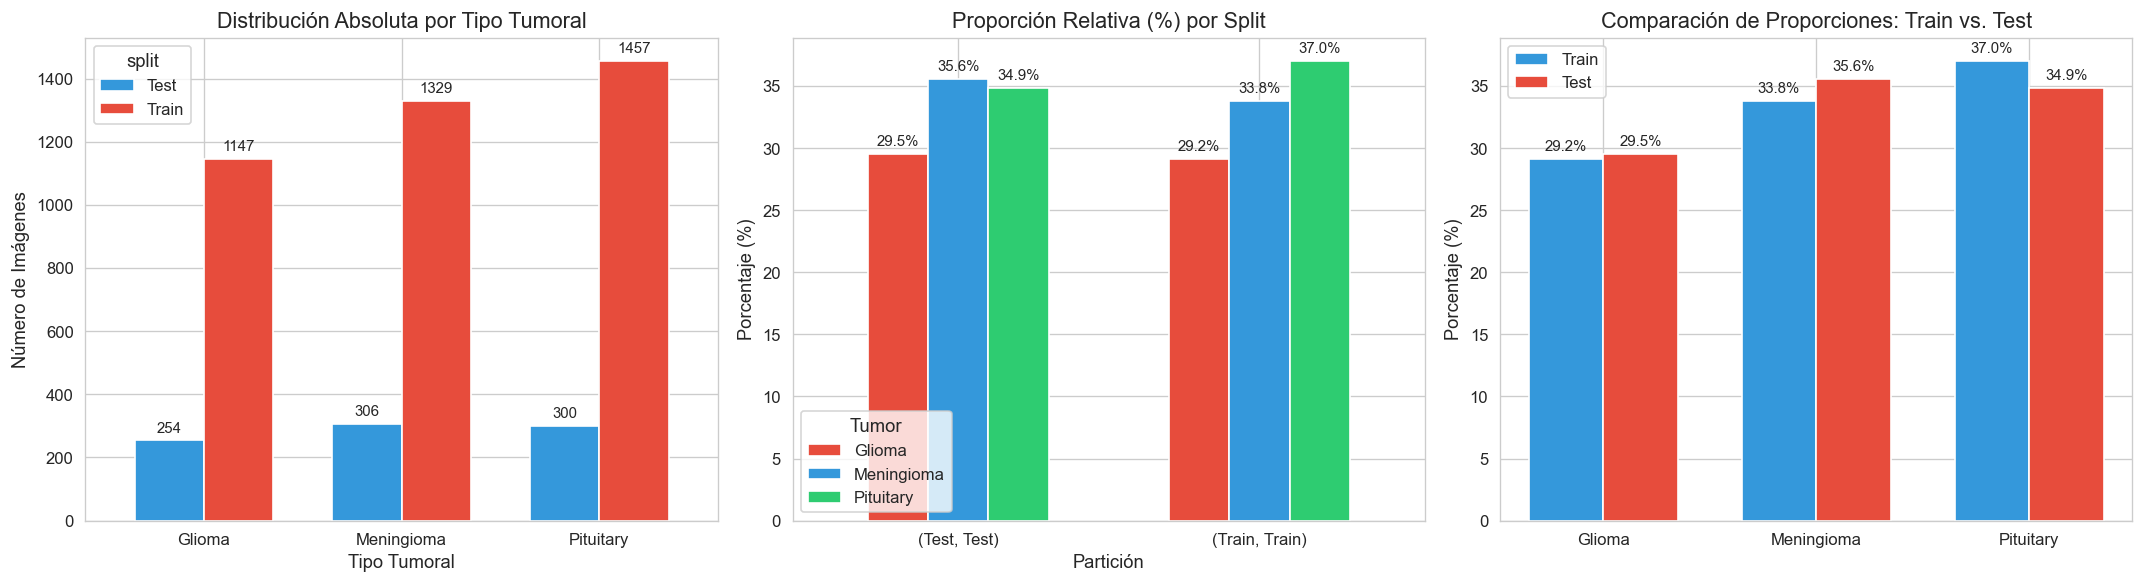


 Tabla de contingencia: Tipo Tumoral × Split
split        Test  Train  Total
tumor_label                    
Glioma        254   1147   1401
Meningioma    306   1329   1635
Pituitary     300   1457   1757
Total         860   3933   4793


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tumor_counts = df.groupby(['tumor_label', 'split']).size().unstack(fill_value=0)
tumor_counts = tumor_counts.reindex(['Glioma', 'Meningioma', 'Pituitary'])

tumor_counts.plot(
    kind='bar', ax=axes[0], color=[SPLIT_PALETTE['Train'], SPLIT_PALETTE['Test']],
    edgecolor='white', width=0.7
)
axes[0].set_title('Distribución Absoluta por Tipo Tumoral')
axes[0].set_xlabel('Tipo Tumoral')
axes[0].set_ylabel('Número de Imágenes')
axes[0].tick_params(axis='x', rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9, padding=3)

tumor_props = df.groupby(['split', 'tumor_label']).size().groupby(level=0).apply(
    lambda x: x / x.sum() * 100
).unstack(fill_value=0)
tumor_props = tumor_props[['Glioma', 'Meningioma', 'Pituitary']]

tumor_props.plot(
    kind='bar', ax=axes[1], color=[TUMOR_PALETTE['Glioma'], TUMOR_PALETTE['Meningioma'], TUMOR_PALETTE['Pituitary']],
    edgecolor='white', width=0.6
)
axes[1].set_title('Proporción Relativa (%) por Split')
axes[1].set_xlabel('Partición')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Tumor')

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

train_props = df[df['split']=='Train']['tumor_label'].value_counts(normalize=True).reindex(['Glioma','Meningioma','Pituitary'])
test_props = df[df['split']=='Test']['tumor_label'].value_counts(normalize=True).reindex(['Glioma','Meningioma','Pituitary'])

x = np.arange(3)
width = 0.35
axes[2].bar(x - width/2, train_props.values*100, width, label='Train', color=SPLIT_PALETTE['Train'], edgecolor='white')
axes[2].bar(x + width/2, test_props.values*100, width, label='Test', color=SPLIT_PALETTE['Test'], edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Glioma', 'Meningioma', 'Pituitary'])
axes[2].set_title('Comparación de Proporciones: Train vs. Test')
axes[2].set_ylabel('Porcentaje (%)')
axes[2].legend()

for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

plt.tight_layout()
plt.savefig('eda_tumor_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
print("\n Tabla de contingencia: Tipo Tumoral × Split")
print("="*55)
ct_tumor = pd.crosstab(df['tumor_label'], df['split'], margins=True, margins_name='Total')
print(ct_tumor.to_string())


### 3.3.2 Distribución por plano anatómico


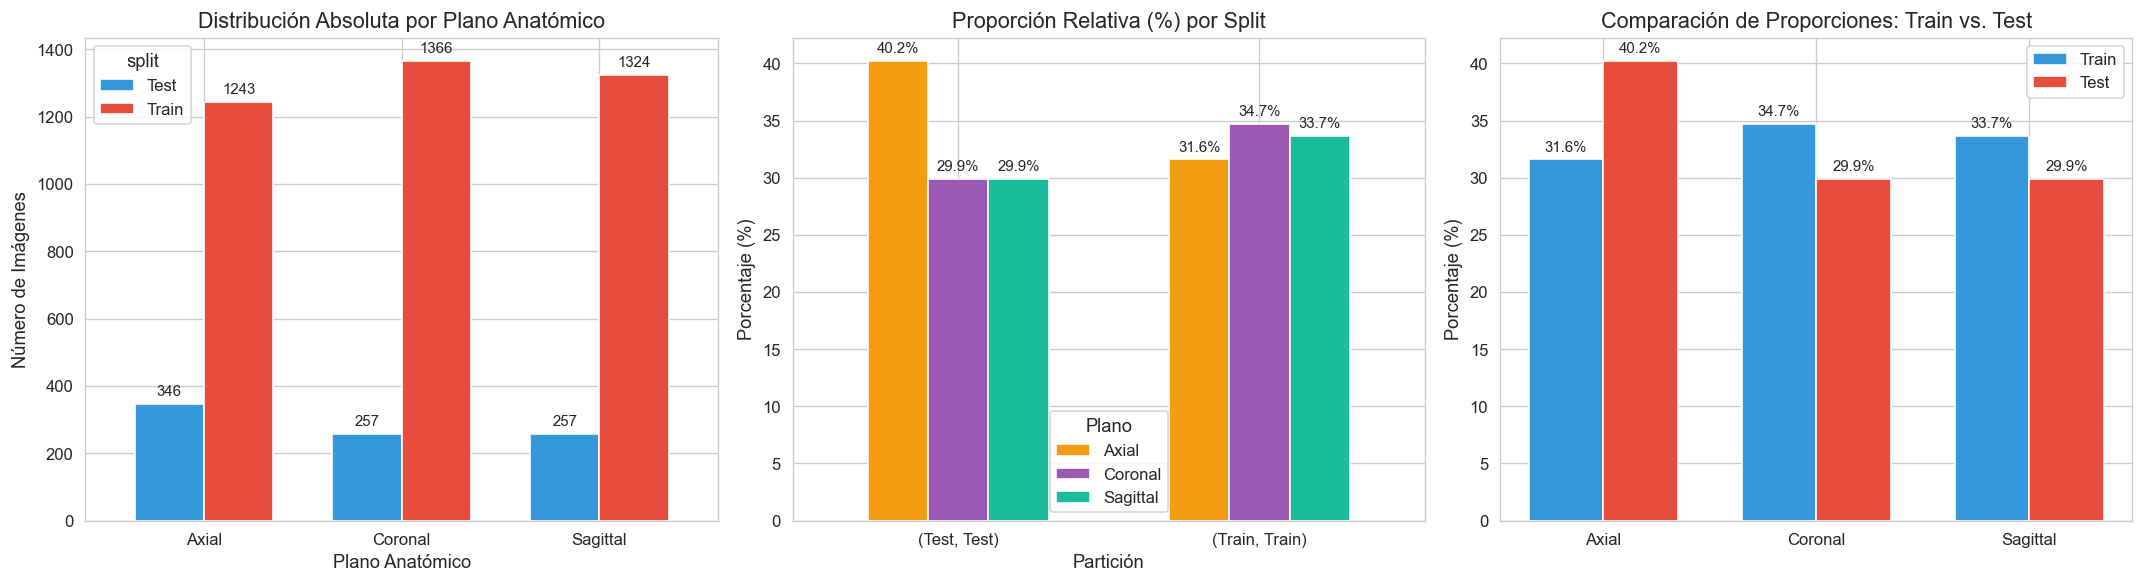


 Tabla de contingencia: Plano Anatómico × Split
split        Test  Train  Total
plane_label                    
Axial         346   1243   1589
Coronal       257   1366   1623
Sagittal      257   1324   1581
Total         860   3933   4793


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plane_counts = df.groupby(['plane_label', 'split']).size().unstack(fill_value=0)
plane_counts = plane_counts.reindex(['Axial', 'Coronal', 'Sagittal'])

plane_counts.plot(
    kind='bar', ax=axes[0], color=[SPLIT_PALETTE['Train'], SPLIT_PALETTE['Test']],
    edgecolor='white', width=0.7
)
axes[0].set_title('Distribución Absoluta por Plano Anatómico')
axes[0].set_xlabel('Plano Anatómico')
axes[0].set_ylabel('Número de Imágenes')
axes[0].tick_params(axis='x', rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9, padding=3)

plane_props = df.groupby(['split', 'plane_label']).size().groupby(level=0).apply(
    lambda x: x / x.sum() * 100
).unstack(fill_value=0)
plane_props = plane_props[['Axial', 'Coronal', 'Sagittal']]

plane_props.plot(
    kind='bar', ax=axes[1], color=[PLANE_PALETTE['Axial'], PLANE_PALETTE['Coronal'], PLANE_PALETTE['Sagittal']],
    edgecolor='white', width=0.6
)
axes[1].set_title('Proporción Relativa (%) por Split')
axes[1].set_xlabel('Partición')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Plano')

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

train_plane = df[df['split']=='Train']['plane_label'].value_counts(normalize=True).reindex(['Axial','Coronal','Sagittal'])
test_plane = df[df['split']=='Test']['plane_label'].value_counts(normalize=True).reindex(['Axial','Coronal','Sagittal'])

x = np.arange(3)
width = 0.35
axes[2].bar(x - width/2, train_plane.values*100, width, label='Train', color=SPLIT_PALETTE['Train'], edgecolor='white')
axes[2].bar(x + width/2, test_plane.values*100, width, label='Test', color=SPLIT_PALETTE['Test'], edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Axial', 'Coronal', 'Sagittal'])
axes[2].set_title('Comparación de Proporciones: Train vs. Test')
axes[2].set_ylabel('Porcentaje (%)')
axes[2].legend()

for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

plt.tight_layout()
plt.savefig('eda_plane_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Tabla de contingencia: Plano Anatómico × Split")
print("="*55)
ct_plane = pd.crosstab(df['plane_label'], df['split'], margins=True, margins_name='Total')
print(ct_plane.to_string())


**Análisis de Clases Tumorales:**
El análisis de distribución revela un ligero predominio de tumores de tipo **Pituitary** ($n=1,757$) frente a **Gliomas** ($n=1,401$). No obstante, las proporciones relativas se mantienen altamente consistentes entre los conjuntos de entrenamiento y prueba (variaciones $<0.5\%$). Esta estabilidad en el *label distribution* asegura que el modelo sea evaluado bajo las mismas condiciones de prevalencia en las que fue entrenado.

**Análisis de Planos Anatómicos:**
Se observa un equilibrio notable en el set de entrenamiento para los tres planos anatómicos (~31-34%). Sin embargo, en el conjunto de prueba, el plano **Axial exhibe una mayor representación (40.2%)** en comparación con el Coronal y Sagital (~29.9% cada uno). Esta asimetría en el test-set deberá ser considerada al reportar el mIoU por plano, ya que los resultados globales estarán más influenciados por el desempeño en cortes axiales. A pesar de esto, la tabla de contingencia confirma que contamos con una base de datos lo suficientemente densa en todas las categorías para un análisis desagregado estadísticamente significativo."

### 3.3.3 Análisis de la Interacción Patología-Plano (Distribución Conjunta)

La validez del análisis de rendimiento desagregado —contribución central de este trabajo— depende de la suficiencia muestral en la interacción de las variables `tumor_label` y `plane_label`. Se emplea un análisis de calor (heatmaps) para inspeccionar la densidad de datos en el espacio bidimensional de las categorías. Este examen es crítico para identificar posibles sesgos de adquisición o desbalances que pudieran comprometer la potencia estadística de las métricas de segmentación por plano anatómico en fases posteriores.


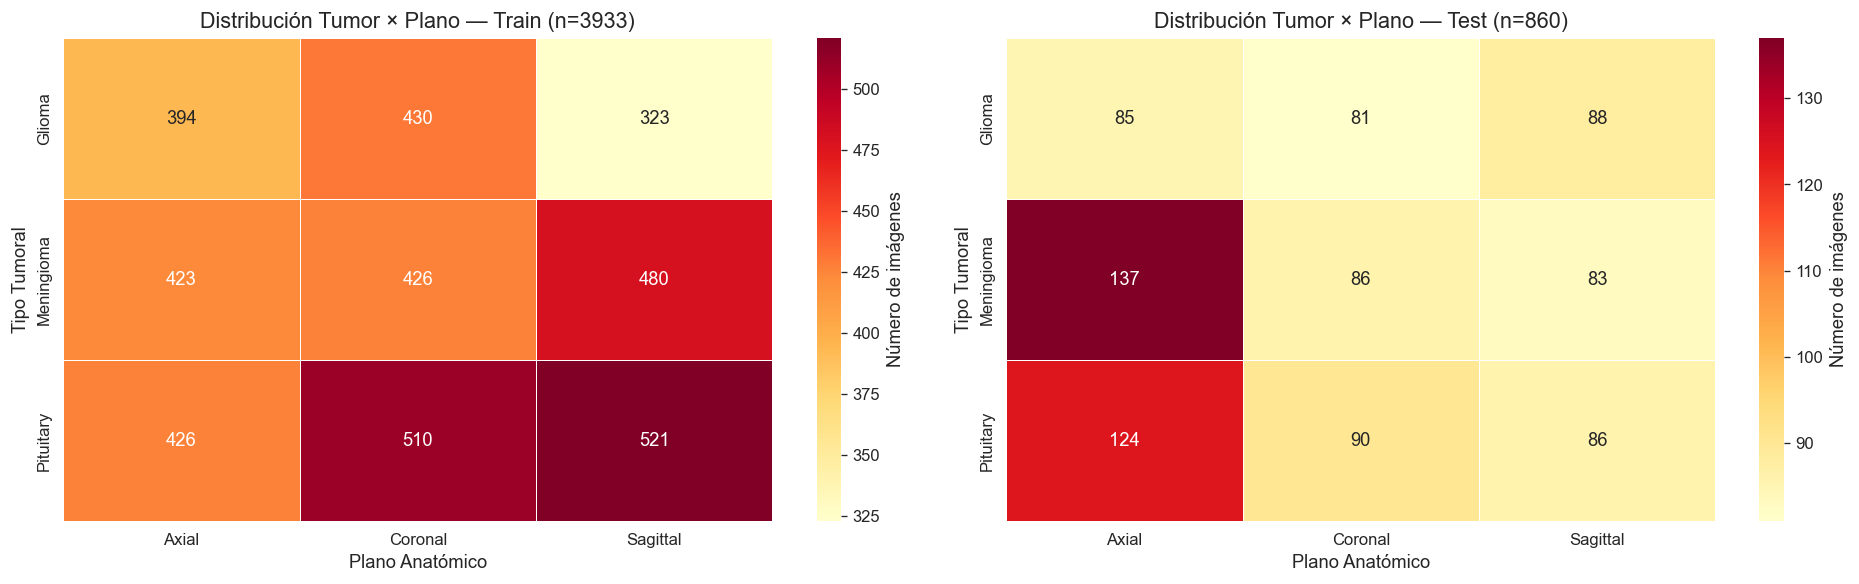


 Distribución completa Tumor × Plano × Split
split                    Test  Train  Total
tumor_label plane_label                    
Glioma      Axial          85    394    479
            Coronal        81    430    511
            Sagittal       88    323    411
Meningioma  Axial         137    423    560
            Coronal        86    426    512
            Sagittal       83    480    563
Pituitary   Axial         124    426    550
            Coronal        90    510    600
            Sagittal       86    521    607
Total                     860   3933   4793


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, split in enumerate(['Train', 'Test']):
    subset = df[df['split'] == split]
    ct = pd.crosstab(subset['tumor_label'], subset['plane_label'])
    ct = ct.reindex(index=['Glioma', 'Meningioma', 'Pituitary'],
                    columns=['Axial', 'Coronal', 'Sagittal'])
    
    sns.heatmap(
        ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[idx],
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Número de imágenes'}
    )
    axes[idx].set_title(f'Distribución Tumor × Plano — {split} (n={len(subset)})')
    axes[idx].set_xlabel('Plano Anatómico')
    axes[idx].set_ylabel('Tipo Tumoral')

plt.tight_layout()
plt.savefig('eda_tumor_plane_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Distribución completa Tumor × Plano × Split")
print("="*70)
full_ct = pd.crosstab(
    [df['tumor_label'], df['plane_label']],
    df['split'],
    margins=True, margins_name='Total'
)
print(full_ct.to_string())


La inspección de la distribución conjunta mediante los mapas de calor,  confirma que las **9 combinaciones posibles** (3 tipos tumorales $\times$ 3 planos anatómicos) poseen una representación robusta en ambos splits. En el conjunto de entrenamiento, el volumen de muestras por celda oscila entre $n=323$ y $n=521$, proporcionando una base densa para el aprendizaje de características morfológicas específicas de cada plano. 

Se identifica una asimetría moderada en el conjunto de prueba, donde las patologías de Meningioma y Pituitary presentan una mayor frecuencia en el plano axial ($n_{me\_ax}=137$; $n_{pi\_ax}=124$). Aunque esta observación sugiere una ligera predominancia de la vista axial en la evaluación final, el volumen mínimo de 81 imágenes por combinación asegura que el cálculo del mIoU y Dice Score por plano mantenga validez estadística y no sea sensible a valores atípicos (outliers) de segmentación.

### 3.3.4 Validación Estadística de Homogeneidad Inter-Split (Prueba χ²)

Para garantizar la validez externa de los resultados de segmentación, se realiza una prueba de independencia Chi-cuadrado ($\chi^2$) de Pearson. El objetivo es determinar si las particiones de entrenamiento y evaluación conservan la misma distribución de probabilidad. Una discrepancia significativa ($p < 0.05$) indicaría un **sesgo de partición (partition bias)** o un **desplazamiento de dominio (domain shift)** inducido, lo cual obligaría a un análisis de métricas ponderadas o a una discusión sobre las limitaciones de generalización del modelo en planos específicos.


In [6]:
def chi2_homogeneity_test(df, variable, var_label):
    """Realiza test Chi-cuadrado de homogeneidad entre Train y Test."""
    ct = pd.crosstab(df[variable], df['split'])
    chi2, p_value, dof, expected = chi2_contingency(ct)
    
    print(f"\n{'='*60}")
    print(f"  Test Chi-cuadrado de Homogeneidad: {var_label}")
    print(f"{'='*60}")
    print(f"  H₀: La distribución de {var_label} es igual en Train y Test")
    print(f"  H₁: La distribución de {var_label} difiere entre Train y Test")
    print(f"{'─'*60}")
    print(f"  Estadístico χ²  = {chi2:.4f}")
    print(f"  Grados de libertad = {dof}")
    print(f"  p-valor         = {p_value:.6f}")
    print(f"{'─'*60}")
    
    if p_value > 0.05:
        print(f"  RESULTADO: No se rechaza H₀ (p = {p_value:.4f} > 0.05)")
        print(f"     Las distribuciones de {var_label} son homogéneas entre splits.")
    else:
        print(f"  RESULTADO: Se rechaza H₀ (p = {p_value:.4f} ≤ 0.05)")
        print(f"     Existe diferencia significativa en la distribución de {var_label}.")
    
    # Mostrar frecuencias esperadas vs observadas
    print(f"\n  Frecuencias observadas vs esperadas:")
    expected_df = pd.DataFrame(
        expected, index=ct.index, columns=ct.columns
    ).round(1)
    comparison = ct.astype(str) + ' (' + expected_df.astype(str) + ')'
    print(comparison.to_string())
    
    return chi2, p_value, dof

chi2_tumor, p_tumor, _ = chi2_homogeneity_test(df, 'tumor_label', 'Tipo Tumoral')

chi2_plane, p_plane, _ = chi2_homogeneity_test(df, 'plane_label', 'Plano Anatómico')

df['tumor_plane'] = df['tumor_label'] + ' × ' + df['plane_label']
chi2_inter, p_inter, _ = chi2_homogeneity_test(df, 'tumor_plane', 'Tumor × Plano (interacción)')



  Test Chi-cuadrado de Homogeneidad: Tipo Tumoral
  H₀: La distribución de Tipo Tumoral es igual en Train y Test
  H₁: La distribución de Tipo Tumoral difiere entre Train y Test
────────────────────────────────────────────────────────────
  Estadístico χ²  = 1.5961
  Grados de libertad = 2
  p-valor         = 0.450207
────────────────────────────────────────────────────────────
  RESULTADO: No se rechaza H₀ (p = 0.4502 > 0.05)
     Las distribuciones de Tipo Tumoral son homogéneas entre splits.

  Frecuencias observadas vs esperadas:
split               Test          Train
tumor_label                            
Glioma       254 (251.4)  1147 (1149.6)
Meningioma   306 (293.4)  1329 (1341.6)
Pituitary    300 (315.3)  1457 (1441.7)

  Test Chi-cuadrado de Homogeneidad: Plano Anatómico
  H₀: La distribución de Plano Anatómico es igual en Train y Test
  H₁: La distribución de Plano Anatómico difiere entre Train y Test
────────────────────────────────────────────────────────────
  Estadíst

Se aplicaron pruebas de homogeneidad $\chi^2$ para validar la consistencia de los datos. Mientras que la distribución de tipos tumorales no mostró diferencias significativas entre particiones ($\chi^2 = 1.60, p = 0.45$), se halló una **asimetría estadísticamente significativa** en la distribución de planos anatómicos ($\chi^2 = 23.80, p < 0.001$). 

Específicamente, el conjunto de prueba presenta una sobre-representación del plano Axial (40.2% observado vs 31.6% esperado). Debido a esta heterogeneidad, este estudio priorizará el reporte de **mIoU por plano** y el **Weighted mIoU** sobre el mIoU global, mitigando así el sesgo inducido por la composición del set de evaluación.

### 3.4 Caracterización de la Heterogeneidad Geométrica y Espacial
La eficiencia de arquitecturas de segmentación como U-Net o Transformer-based models depende de la estandarización de los inputs. En esta sección, se cuantifican las propiedades espaciales del dataset BRISC 2025, analizando la variabilidad en las resoluciones nativas, la preservación de la relación de aspecto (aspect ratio) y la profundidad de bits (modos de color). Este diagnóstico es fundamental para definir la estrategia de redimensionamiento y normalización, asegurando que no se introduzcan distorsiones morfológicas que puedan alterar la delimitación precisa del volumen tumoral.

In [7]:
spatial_data = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Leyendo dimensiones"):
    try:
        with Image.open(row['image_path']) as img:
            w, h = img.size
            mode = img.mode
        
        file_size = os.path.getsize(row['image_path']) / 1024  # KB
        
        spatial_data.append({
            'width': w,
            'height': h,
            'aspect_ratio': w / h,
            'resolution': f"{w}×{h}",
            'num_pixels': w * h,
            'color_mode': mode,
            'file_size_kb': file_size,
        })
    except Exception as e:
        spatial_data.append({
            'width': None, 'height': None, 'aspect_ratio': None,
            'resolution': 'ERROR', 'num_pixels': None,
            'color_mode': None, 'file_size_kb': None,
        })

df_spatial = pd.DataFrame(spatial_data)
df = pd.concat([df, df_spatial], axis=1)

# --- Resumen de dimensiones ---
print("\n Resumen de Dimensiones de Imágenes")
print("="*55)
print(f"  Resoluciones únicas encontradas: {df['resolution'].nunique()}")
print(f"\n  Distribución de resoluciones:")
res_counts = df['resolution'].value_counts()
for res, count in res_counts.items():
    print(f"    {res}: {count} imágenes ({count/len(df)*100:.1f}%)")

print(f"\n  Modos de color únicos: {df['color_mode'].unique()}")
print(f"\n  Tamaño de archivo (KB):")
print(f"    Media:   {df['file_size_kb'].mean():.1f} KB")
print(f"    Mediana: {df['file_size_kb'].median():.1f} KB")
print(f"    Min:     {df['file_size_kb'].min():.1f} KB")
print(f"    Max:     {df['file_size_kb'].max():.1f} KB")
print(f"    Std:     {df['file_size_kb'].std():.1f} KB")


Leyendo dimensiones:   0%|          | 0/4793 [00:00<?, ?it/s]

Leyendo dimensiones: 100%|██████████| 4793/4793 [00:05<00:00, 870.89it/s]


 Resumen de Dimensiones de Imágenes
  Resoluciones únicas encontradas: 140

  Distribución de resoluciones:
    512×512: 4504 imágenes (94.0%)
    256×256: 30 imágenes (0.6%)
    225×225: 15 imágenes (0.3%)
    442×442: 8 imágenes (0.2%)
    201×251: 5 imágenes (0.1%)
    455×500: 5 imágenes (0.1%)
    554×554: 5 imágenes (0.1%)
    212×237: 4 imágenes (0.1%)
    200×223: 4 imágenes (0.1%)
    341×395: 4 imágenes (0.1%)
    210×240: 4 imágenes (0.1%)
    213×237: 3 imágenes (0.1%)
    722×690: 2 imágenes (0.0%)
    591×650: 2 imágenes (0.0%)
    338×345: 2 imágenes (0.0%)
    369×398: 2 imágenes (0.0%)
    441×427: 2 imágenes (0.0%)
    485×510: 2 imágenes (0.0%)
    472×546: 2 imágenes (0.0%)
    507×605: 2 imágenes (0.0%)
    291×340: 2 imágenes (0.0%)
    318×354: 2 imágenes (0.0%)
    315×341: 2 imágenes (0.0%)
    278×306: 2 imágenes (0.0%)
    312×401: 2 imágenes (0.0%)
    257×307: 2 imágenes (0.0%)
    491×624: 2 imágenes (0.0%)
    314×358: 2 imágenes (0.0%)
    208×243: 2 im

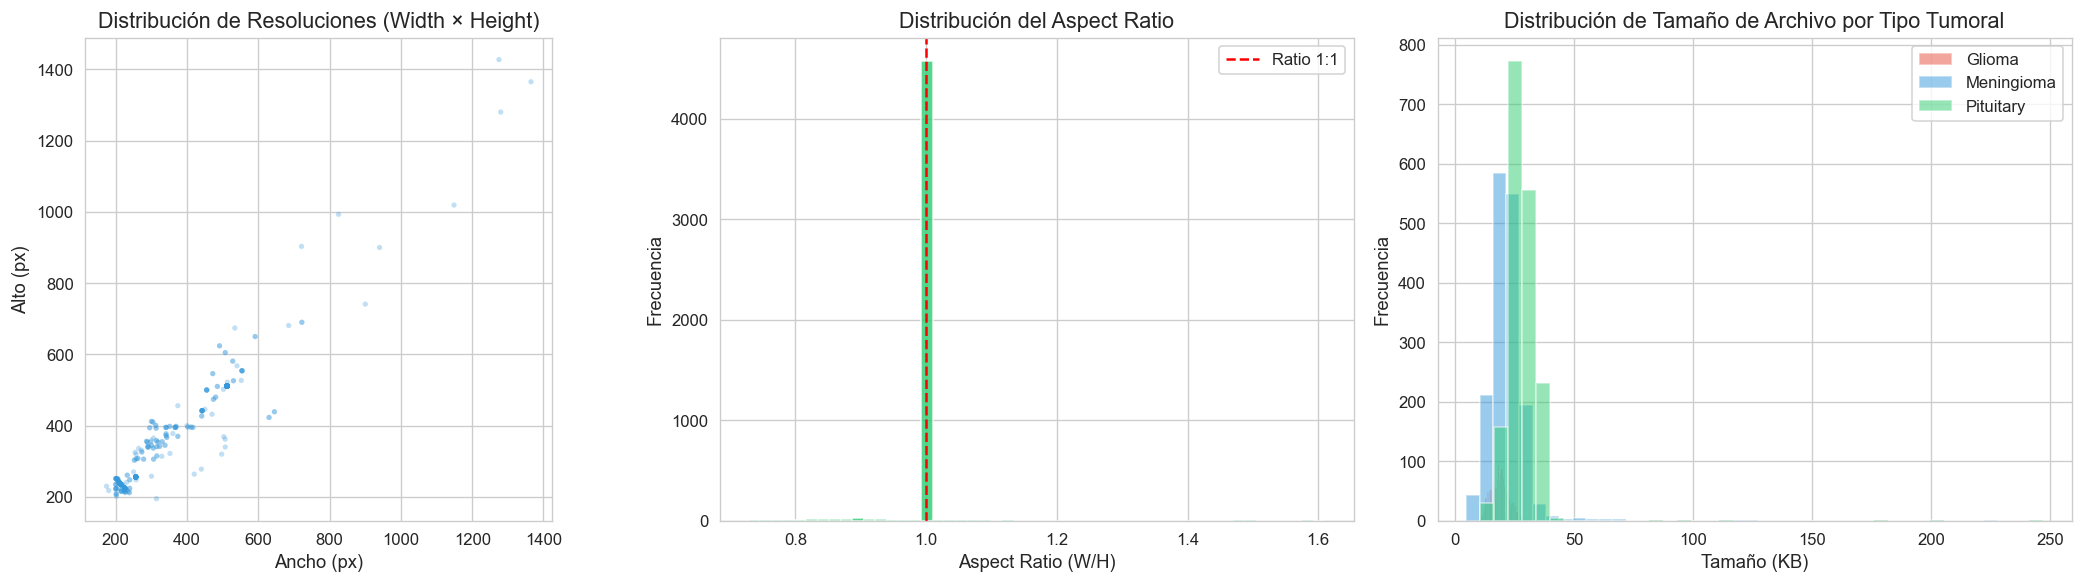

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['width'], df['height'], alpha=0.3, s=10, c='#3498DB', edgecolors='none')
axes[0].set_title('Distribución de Resoluciones (Width × Height)')
axes[0].set_xlabel('Ancho (px)')
axes[0].set_ylabel('Alto (px)')
axes[0].set_aspect('equal')

axes[1].hist(df['aspect_ratio'].dropna(), bins=50, color='#2ECC71', edgecolor='white', alpha=0.8)
axes[1].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Ratio 1:1')
axes[1].set_title('Distribución del Aspect Ratio')
axes[1].set_xlabel('Aspect Ratio (W/H)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

for tumor in ['Glioma', 'Meningioma', 'Pituitary']:
    subset = df[df['tumor_label'] == tumor]['file_size_kb'].dropna()
    axes[2].hist(subset, bins=40, alpha=0.5, label=tumor, color=TUMOR_PALETTE[tumor], edgecolor='white')

axes[2].set_title('Distribución de Tamaño de Archivo por Tipo Tumoral')
axes[2].set_xlabel('Tamaño (KB)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_spatial_properties.png', dpi=150, bbox_inches='tight')
plt.show()


El análisis de las propiedades espaciales revela que el dataset BRISC 2025 presenta una alta consistencia geométrica, con el **94.0% de las imágenes ($n=4504$) en una resolución nativa de $512 \times 512$ píxeles**. A pesar de existir 140 variantes de resolución, la distribución del *aspect ratio* se concentra fuertemente en el valor unitario ($1.0$), lo que indica que la gran mayoría de las capturas son cuadradas.

Sin embargo, se identificaron dos desafíos técnicos relevantes:
1.  **Variabilidad de Resolución:** La presencia de imágenes con dimensiones reducidas ($180 \times 218$) y elevadas ($1365 \times 1365$) confirma la necesidad de un proceso de interpolación bilinear para estandarizar el input del modelo.
2.  **Inconsistencia en Canales:** La coexistencia de modos de color RGB y L (escala de grises) sugiere una disparidad en la codificación de los archivos `.jpg`. 

Estos hallazgos dictan que el pipeline de preprocesamiento debe incluir una conversión mandatoria a un solo canal y un redimensionamiento uniforme, mitigando así el riesgo de errores de memoria en la GPU y garantizando la homogeneidad del tensor de entrada.


## 3.5 Caracterización Radiométrica y Variabilidad Inter-Clase

La consistencia en la intensidad de los píxeles es un factor determinante para la generalización de los modelos de Deep Learning. En esta sección, se realiza una caracterización radiométrica profunda mediante el cálculo de momentos estadísticos (media, desviación estándar, asimetría y curtosis) y el porcentaje de fondo (*pct_black*). 

El análisis se desglosa por tipo tumoral y plano anatómico para detectar **sesgos de adquisición**. La identificación de diferencias significativas en estos estadísticos es crítica para justificar la necesidad de técnicas de estandarización de intensidad, asegurando que el modelo aprenda características morfológicas del tumor y no variaciones técnicas en el brillo o contraste de las resonancias.


In [9]:
intensity_stats = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Analizando intensidades"):
    try:
        img = np.array(Image.open(row['image_path']).convert('L'))  # Grayscale
        img_norm = img.astype(np.float32) / 255.0
        
        intensity_stats.append({
            'mean_intensity':   np.mean(img_norm),
            'std_intensity':    np.std(img_norm),
            'median_intensity': np.median(img_norm),
            'min_intensity':    np.min(img_norm),
            'max_intensity':    np.max(img_norm),
            'skewness':         float(stats.skew(img_norm.flatten())),
            'kurtosis':         float(stats.kurtosis(img_norm.flatten())),
            'pct_black':        np.mean(img_norm < 0.05) * 100,  # % píxeles casi negros
        })
    except Exception as e:
        intensity_stats.append({k: None for k in [
            'mean_intensity', 'std_intensity', 'median_intensity',
            'min_intensity', 'max_intensity', 'skewness', 'kurtosis', 'pct_black'
        ]})

df_intensity = pd.DataFrame(intensity_stats)
df = pd.concat([df.reset_index(drop=True), df_intensity], axis=1)

# Resumen
print("\n Estadísticos de Intensidad (valores normalizados [0, 1])")
print("="*65)
intensity_summary = df[['mean_intensity', 'std_intensity', 'skewness', 'kurtosis', 'pct_black']].describe().round(4)
print(intensity_summary.to_string())


Analizando intensidades: 100%|██████████| 4793/4793 [00:53<00:00, 89.50it/s] 


 Estadísticos de Intensidad (valores normalizados [0, 1])
       mean_intensity  std_intensity   skewness   kurtosis  pct_black
count       4793.0000      4793.0000  4793.0000  4793.0000  4793.0000
mean           0.1687         0.1675     1.0054     0.8841    44.0535
std            0.0521         0.0298     0.3545     1.0051    14.3682
min            0.0537         0.0817    -0.6237    -1.5548     0.0000
25%            0.1332         0.1504     0.7760     0.2111    33.7166
50%            0.1645         0.1650     1.0008     0.7060    44.8463
75%            0.1975         0.1809     1.2159     1.4075    54.8790
max            0.5403         0.3563     2.8971     8.0276    82.9796


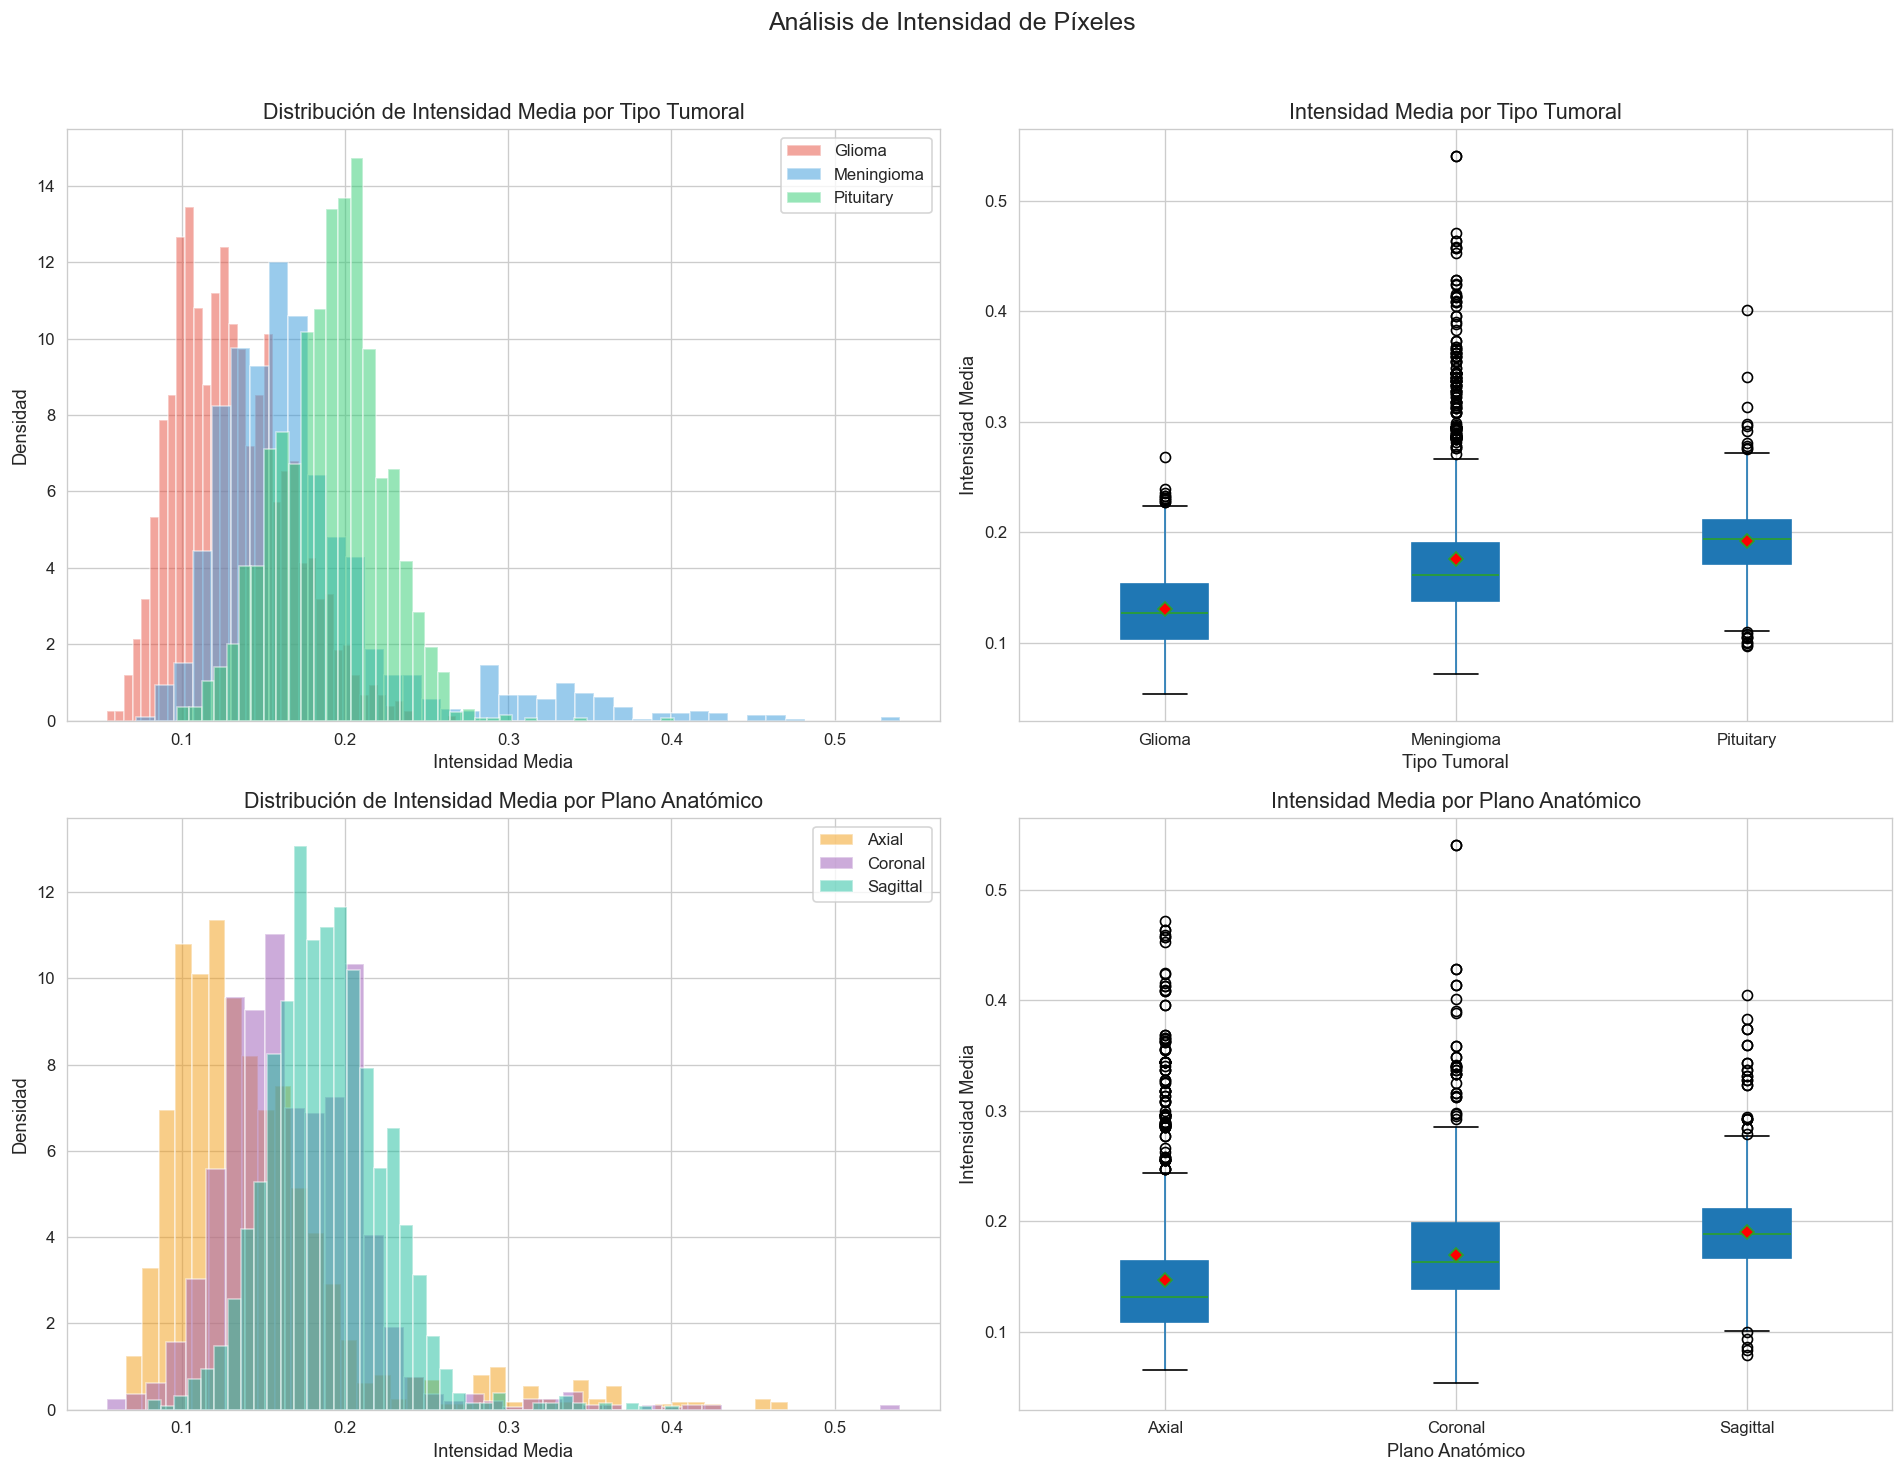

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for tumor in ['Glioma', 'Meningioma', 'Pituitary']:
    subset = df[df['tumor_label'] == tumor]['mean_intensity'].dropna()
    axes[0, 0].hist(subset, bins=40, alpha=0.5, label=tumor, color=TUMOR_PALETTE[tumor], density=True)
axes[0, 0].set_title('Distribución de Intensidad Media por Tipo Tumoral')
axes[0, 0].set_xlabel('Intensidad Media')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].legend()

df.boxplot(column='mean_intensity', by='tumor_label', ax=axes[0, 1],
           patch_artist=True, showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
axes[0, 1].set_title('Intensidad Media por Tipo Tumoral')
axes[0, 1].set_xlabel('Tipo Tumoral')
axes[0, 1].set_ylabel('Intensidad Media')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

for plane in ['Axial', 'Coronal', 'Sagittal']:
    subset = df[df['plane_label'] == plane]['mean_intensity'].dropna()
    axes[1, 0].hist(subset, bins=40, alpha=0.5, label=plane, color=PLANE_PALETTE[plane], density=True)
axes[1, 0].set_title('Distribución de Intensidad Media por Plano Anatómico')
axes[1, 0].set_xlabel('Intensidad Media')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].legend()

df.boxplot(column='mean_intensity', by='plane_label', ax=axes[1, 1],
           patch_artist=True, showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
axes[1, 1].set_title('Intensidad Media por Plano Anatómico')
axes[1, 1].set_xlabel('Plano Anatómico')
axes[1, 1].set_ylabel('Intensidad Media')
plt.sca(axes[1, 1])
plt.xticks(rotation=0)

fig.suptitle('Análisis de Intensidad de Píxeles', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('eda_intensity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# ============================================================
# 5.2 ESTADÍSTICOS DE INTENSIDAD AGRUPADOS
# ============================================================

print(" Estadísticos de Intensidad por Tipo Tumoral")
print("="*75)
tumor_stats = df.groupby('tumor_label')[
    ['mean_intensity', 'std_intensity', 'skewness', 'kurtosis', 'pct_black']
].agg(['mean', 'std']).round(4)
print(tumor_stats.to_string())

print("\n\n Estadísticos de Intensidad por Plano Anatómico")
print("="*75)
plane_stats = df.groupby('plane_label')[
    ['mean_intensity', 'std_intensity', 'skewness', 'kurtosis', 'pct_black']
].agg(['mean', 'std']).round(4)
print(plane_stats.to_string())


 Estadísticos de Intensidad por Tipo Tumoral
            mean_intensity         std_intensity         skewness         kurtosis         pct_black         
                      mean     std          mean     std     mean     std     mean     std      mean      std
tumor_label                                                                                                  
Glioma              0.1308  0.0340        0.1521  0.0224   1.2016  0.3183   1.3164  1.0499   52.6359  10.4077
Meningioma          0.1761  0.0630        0.1864  0.0348   1.0563  0.3529   0.7443  0.9672   47.5465  14.4143
Pituitary           0.1920  0.0322        0.1624  0.0188   0.8015  0.2673   0.6696  0.8913   33.9597  10.5645


 Estadísticos de Intensidad por Plano Anatómico
            mean_intensity         std_intensity         skewness         kurtosis         pct_black         
                      mean     std          mean     std     mean     std     mean     std      mean      std
plane_label              

El análisis cuantitativo de las intensidades confirma disparidades radiométricas significativas entre los grupos de estudio. 

**Variabilidad por Patología:**
Los tumores de tipo **Pituitary** exhiben la mayor intensidad media ($\mu=0.1920 \pm 0.0322$) y la menor proporción de fondo negro ($33.9\%$), lo que sugiere una mayor densidad de tejido cerebral visible en estas tomas. En contraste, los **Gliomas** presentan valores significativamente más bajos ($\mu=0.1308 \pm 0.0340$) y una asimetría (*skewness*) más pronunciada ($1.20$), indicando una distribución de píxeles más cargada hacia los tonos oscuros.

**Variabilidad por Plano Anatómico:**
Se observa un gradiente de intensidad condicionado por el plano de adquisición. El plano **Sagital** es el más brillante ($\mu=0.1899$), mientras que el **Axial** presenta la mayor cantidad de píxeles negros ($53.3\%$). Esta diferencia en la relación señal-ruido/fondo entre planos confirma que el modelo de segmentación enfrentará condiciones de contraste heterogéneas dependiendo de la vista procesada.

**Conclusión para el Preprocesamiento:**
Dada la desviación estándar observada (especialmente en Meningiomas, $\sigma=0.0630$), se descarta el uso de normalización global. Estos resultados justifican la implementación de una **Normalización Z-score por instancia**, la cual centrará las distribuciones de cada imagen individualmente, eliminando los sesgos de brillo detectados entre patologías y planos.

## 3.6 Análisis Morfométrico y Desbalance de Clases a Nivel de Píxel

La variable objetivo del proyecto presenta un desafío de **extrema escasez (sparsity)**. En esta sección se cuantifica el *Tumor Ratio*, definido como la proporción de píxeles pertenecientes a la lesión frente al total de la imagen. Este análisis es fundamental para la selección de la función de pérdida: dado que el tejido sano (fondo) predomina masivamente, funciones de pérdida tradicionales como *Binary Cross-Entropy* podrían converger a soluciones triviales. Los resultados aquí presentados justifican el uso de métricas de solapamiento como el *Dice Coefficient* y funciones de pérdida robustas al desbalance de clases.



In [12]:
mask_stats = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Analizando máscaras"):
    try:
        mask = np.array(Image.open(row['mask_path']).convert('L'))
        
        binary_mask = (mask > 127).astype(np.uint8)
        
        total_pixels = binary_mask.size
        tumor_pixels = binary_mask.sum()
        bg_pixels = total_pixels - tumor_pixels
        
        mask_stats.append({
            'mask_width':       mask.shape[1],
            'mask_height':      mask.shape[0],
            'tumor_pixels':     int(tumor_pixels),
            'bg_pixels':        int(bg_pixels),
            'total_pixels':     int(total_pixels),
            'tumor_ratio':      tumor_pixels / total_pixels,
            'bg_ratio':         bg_pixels / total_pixels,
            'is_empty_mask':    tumor_pixels == 0,
            'is_full_mask':     tumor_pixels == total_pixels,
            'unique_values':    len(np.unique(mask)),
        })
    except Exception as e:
        mask_stats.append({k: None for k in [
            'mask_width', 'mask_height', 'tumor_pixels', 'bg_pixels',
            'total_pixels', 'tumor_ratio', 'bg_ratio', 'is_empty_mask',
            'is_full_mask', 'unique_values'
        ]})

df_masks = pd.DataFrame(mask_stats)
df = pd.concat([df.reset_index(drop=True), df_masks], axis=1)

print("\n Resumen de Máscaras de Segmentación")
print("="*55)
print(f"  Total de máscaras analizadas: {len(df)}")
print(f"  Máscaras vacías (sin tumor):  {df['is_empty_mask'].sum()}")
print(f"  Máscaras completas (todo tumor): {df['is_full_mask'].sum()}")
print(f"  Valores únicos en máscaras:   {df['unique_values'].describe()[['min','max','mean']].to_dict()}")

print(f"\n  Tumor Ratio (proporción tumor/imagen):")
print(f"    Media:   {df['tumor_ratio'].mean():.4f} ({df['tumor_ratio'].mean()*100:.2f}%)")
print(f"    Mediana: {df['tumor_ratio'].median():.4f} ({df['tumor_ratio'].median()*100:.2f}%)")
print(f"    Std:     {df['tumor_ratio'].std():.4f}")
print(f"    Min:     {df['tumor_ratio'].min():.6f} ({df['tumor_ratio'].min()*100:.4f}%)")
print(f"    Max:     {df['tumor_ratio'].max():.4f} ({df['tumor_ratio'].max()*100:.2f}%)")


Analizando máscaras: 100%|██████████| 4793/4793 [00:19<00:00, 248.00it/s]


 Resumen de Máscaras de Segmentación
  Total de máscaras analizadas: 4793
  Máscaras vacías (sin tumor):  0
  Máscaras completas (todo tumor): 0
  Valores únicos en máscaras:   {'min': 10.0, 'max': 18.0, 'mean': 14.880033382015439}

  Tumor Ratio (proporción tumor/imagen):
    Media:   0.0169 (1.69%)
    Mediana: 0.0126 (1.26%)
    Std:     0.0150
    Min:     0.000088 (0.0088%)
    Max:     0.1735 (17.35%)


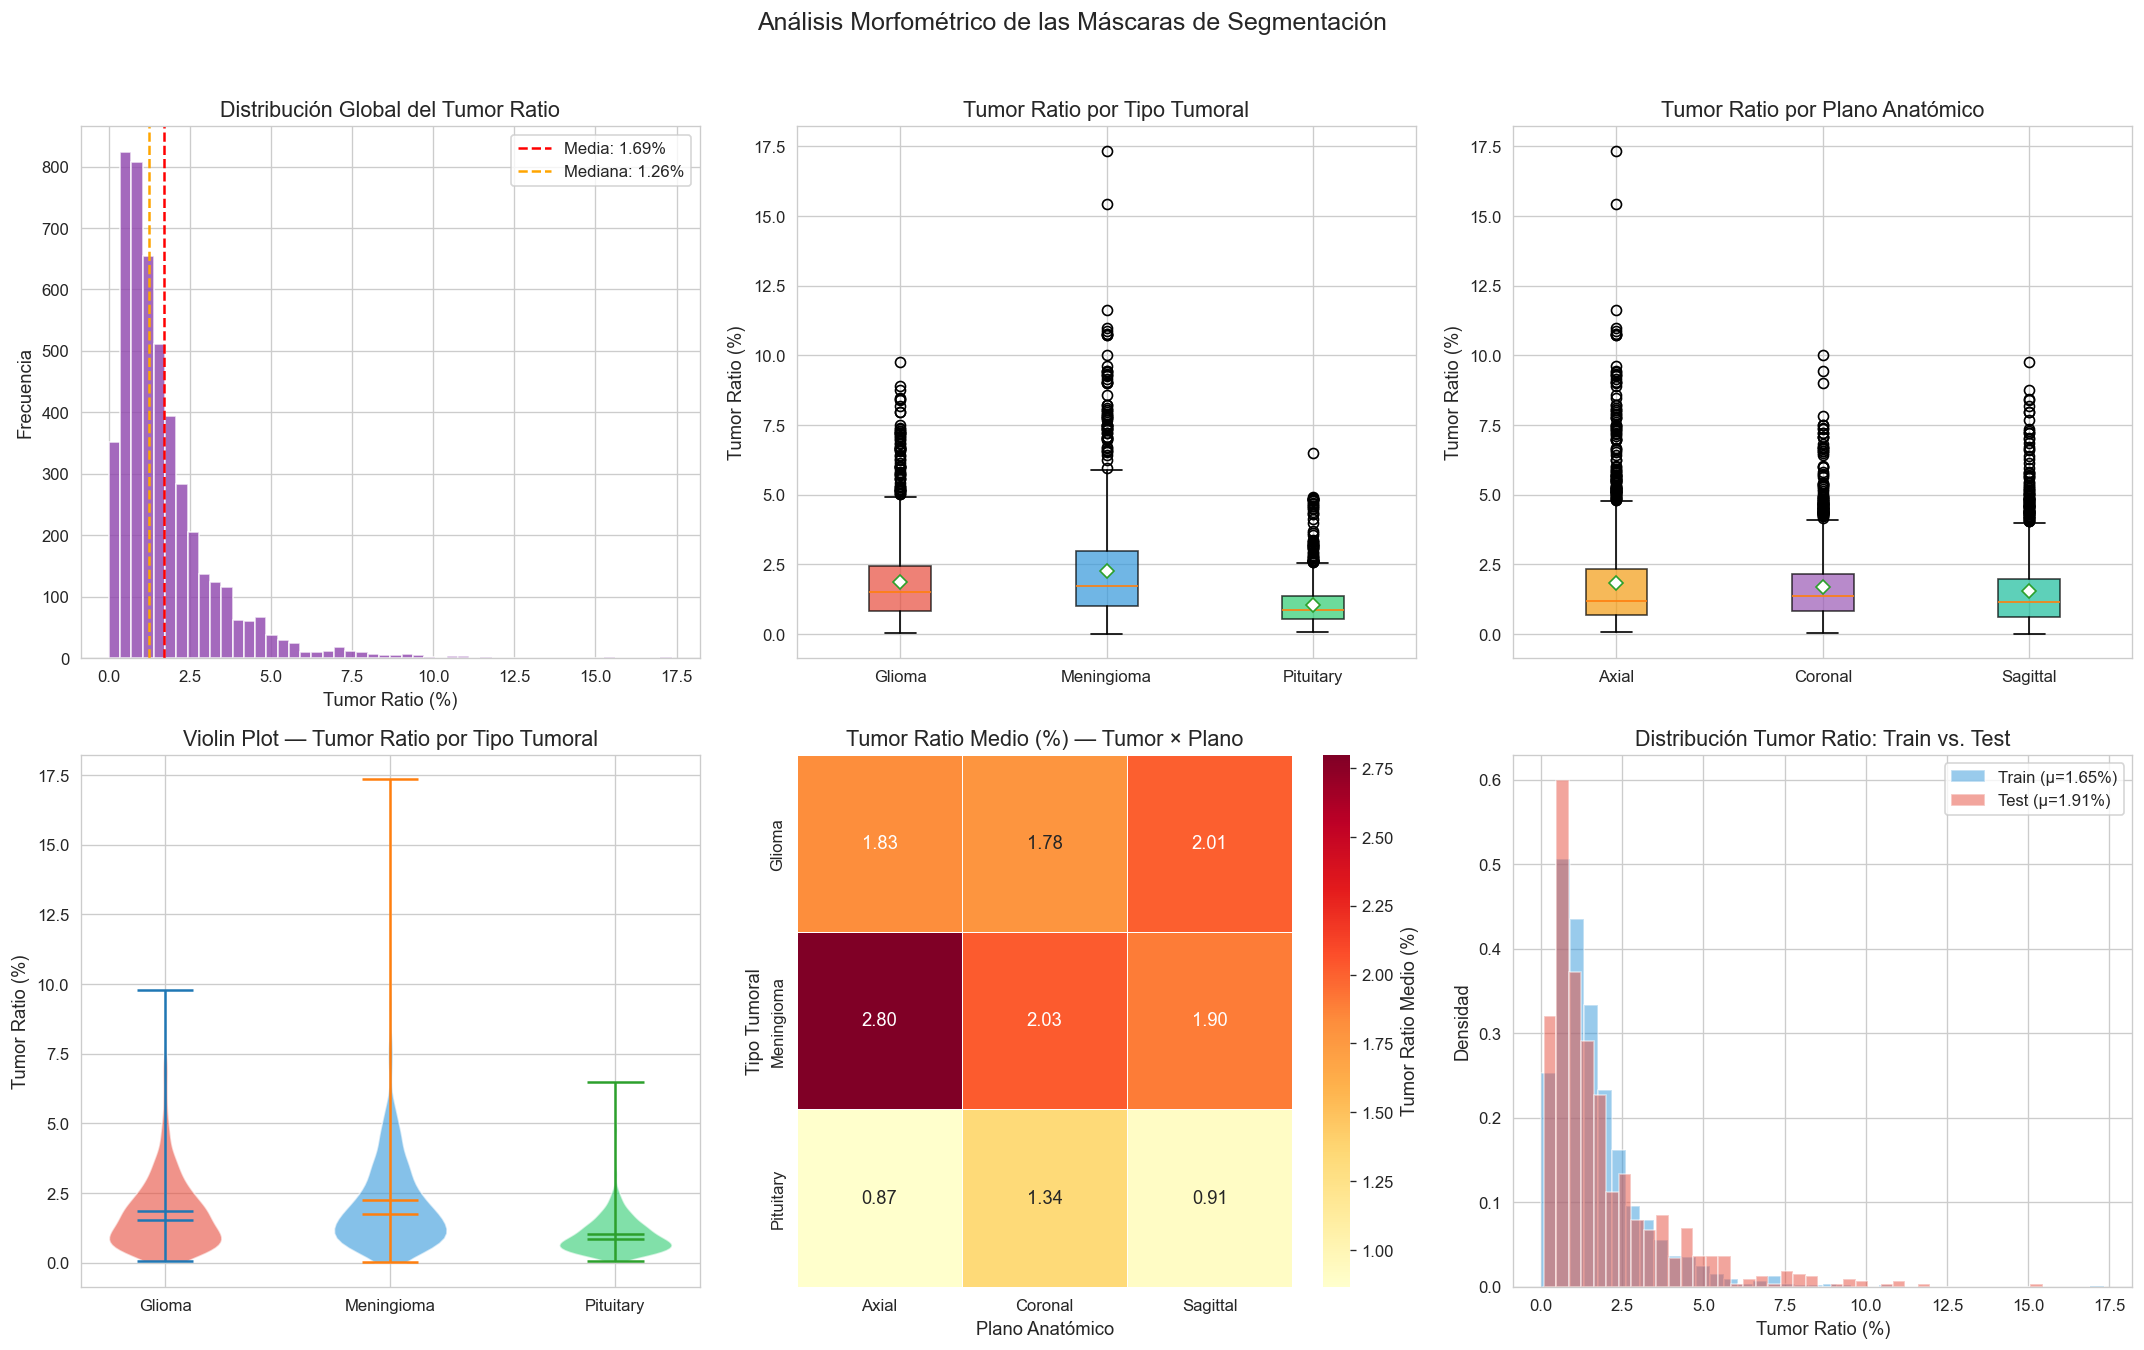

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

axes[0, 0].hist(df['tumor_ratio'].dropna() * 100, bins=50, color='#8E44AD', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(df['tumor_ratio'].mean()*100, color='red', linestyle='--', linewidth=1.5,
                    label=f"Media: {df['tumor_ratio'].mean()*100:.2f}%")
axes[0, 0].axvline(df['tumor_ratio'].median()*100, color='orange', linestyle='--', linewidth=1.5,
                    label=f"Mediana: {df['tumor_ratio'].median()*100:.2f}%")
axes[0, 0].set_title('Distribución Global del Tumor Ratio')
axes[0, 0].set_xlabel('Tumor Ratio (%)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

data_tumor = [df[df['tumor_label']==t]['tumor_ratio'].dropna()*100 for t in ['Glioma','Meningioma','Pituitary']]
bp1 = axes[0, 1].boxplot(data_tumor, labels=['Glioma','Meningioma','Pituitary'],
                          patch_artist=True, showmeans=True,
                          meanprops=dict(marker='D', markerfacecolor='white', markersize=6))
for patch, color in zip(bp1['boxes'], [TUMOR_PALETTE[t] for t in ['Glioma','Meningioma','Pituitary']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_title('Tumor Ratio por Tipo Tumoral')
axes[0, 1].set_ylabel('Tumor Ratio (%)')

data_plane = [df[df['plane_label']==p]['tumor_ratio'].dropna()*100 for p in ['Axial','Coronal','Sagittal']]
bp2 = axes[0, 2].boxplot(data_plane, labels=['Axial','Coronal','Sagittal'],
                          patch_artist=True, showmeans=True,
                          meanprops=dict(marker='D', markerfacecolor='white', markersize=6))
for patch, color in zip(bp2['boxes'], [PLANE_PALETTE[p] for p in ['Axial','Coronal','Sagittal']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 2].set_title('Tumor Ratio por Plano Anatómico')
axes[0, 2].set_ylabel('Tumor Ratio (%)')

for i, tumor in enumerate(['Glioma', 'Meningioma', 'Pituitary']):
    subset = df[df['tumor_label'] == tumor]['tumor_ratio'].dropna() * 100
    parts = axes[1, 0].violinplot([subset], positions=[i], showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(TUMOR_PALETTE[tumor])
        pc.set_alpha(0.6)
axes[1, 0].set_xticks([0, 1, 2])
axes[1, 0].set_xticklabels(['Glioma', 'Meningioma', 'Pituitary'])
axes[1, 0].set_title('Violin Plot — Tumor Ratio por Tipo Tumoral')
axes[1, 0].set_ylabel('Tumor Ratio (%)')

heatmap_data = df.pivot_table(values='tumor_ratio', index='tumor_label', columns='plane_label', aggfunc='mean') * 100
heatmap_data = heatmap_data.reindex(index=['Glioma','Meningioma','Pituitary'], columns=['Axial','Coronal','Sagittal'])
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1, 1],
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Tumor Ratio Medio (%)'})
axes[1, 1].set_title('Tumor Ratio Medio (%) — Tumor × Plano')
axes[1, 1].set_xlabel('Plano Anatómico')
axes[1, 1].set_ylabel('Tipo Tumoral')

for split, color in SPLIT_PALETTE.items():
    subset = df[df['split'] == split]['tumor_ratio'].dropna() * 100
    axes[1, 2].hist(subset, bins=40, alpha=0.5, label=f'{split} (μ={subset.mean():.2f}%)',
                    color=color, density=True, edgecolor='white')
axes[1, 2].set_title('Distribución Tumor Ratio: Train vs. Test')
axes[1, 2].set_xlabel('Tumor Ratio (%)')
axes[1, 2].set_ylabel('Densidad')
axes[1, 2].legend()

fig.suptitle('Análisis Morfométrico de las Máscaras de Segmentación', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('eda_mask_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# --- 1. Estadísticos por Tipo Tumoral ---
print(" Tumor Ratio (%) — Estadísticos por Tipo Tumoral")
print("="*70)
tumor_ratio_stats = df.groupby('tumor_label')['tumor_ratio'].describe()
# Multiplicamos por 100 todas las columnas excepto la primera ('count')
tumor_ratio_stats.iloc[:, 1:] *= 100 
tumor_ratio_stats.columns = ['Count', 'Mean%', 'Std%', 'Min%', '25%', '50%', '75%', 'Max%']
print(tumor_ratio_stats.round(2).to_string())

# --- 2. Estadísticos por Plano Anatómico ---
print("\n\n Tumor Ratio (%) — Estadísticos por Plano Anatómico")
print("="*70)
plane_ratio_stats = df.groupby('plane_label')['tumor_ratio'].describe()
plane_ratio_stats.iloc[:, 1:] *= 100
plane_ratio_stats.columns = ['Count', 'Mean%', 'Std%', 'Min%', '25%', '50%', '75%', 'Max%']
print(plane_ratio_stats.round(2).to_string())

# --- 3. Estadísticos por Tumor × Plano (Interacción) ---
print("\n\n Tumor Ratio (%) — Estadísticos por Tumor × Plano")
print("="*70)
# Usamos una aproximación más directa sin el parche del / 100
cross_ratio = df.groupby(['tumor_label', 'plane_label'])['tumor_ratio'].agg(
    ['count', 'mean', 'std', 'median', 'min', 'max']
)
# Aplicamos el formato solo a las columnas de métricas
cols_to_fix = ['mean', 'std', 'median', 'min', 'max']
cross_ratio[cols_to_fix] *= 100
cross_ratio.columns = ['Count', 'Mean%', 'Std%', 'Median%', 'Min%', 'Max%']
print(cross_ratio.round(2).to_string())


 Tumor Ratio (%) — Estadísticos por Tipo Tumoral
              Count  Mean%  Std%  Min%   25%   50%   75%   Max%
tumor_label                                                    
Glioma       1401.0   1.87  1.48  0.05  0.82  1.52  2.46   9.77
Meningioma   1635.0   2.25  1.83  0.01  1.00  1.74  2.98  17.35
Pituitary    1757.0   1.04  0.73  0.06  0.54  0.86  1.35   6.49


 Tumor Ratio (%) — Estadísticos por Plano Anatómico
              Count  Mean%  Std%  Min%   25%   50%   75%   Max%
plane_label                                                    
Axial        1589.0   1.84  1.82  0.06  0.68  1.20  2.33  17.35
Coronal      1623.0   1.70  1.27  0.05  0.82  1.37  2.14  10.00
Sagittal     1581.0   1.55  1.33  0.01  0.62  1.15  1.97   9.77


 Tumor Ratio (%) — Estadísticos por Tumor × Plano
                         Count  Mean%  Std%  Median%  Min%   Max%
tumor_label plane_label                                          
Glioma      Axial          479   1.83  1.45     1.45  0.10   8.89
       

El análisis morfométrico (Fig. X) revela que la segmentación de tumores en el dataset BRISC 2025 es un problema de **clases altamente desbalanceadas a nivel de píxel**. 

1.  **Sparsity del Objetivo:** El *Tumor Ratio* medio es de apenas **1.69%** ($\sigma=1.5\%$), con una mediana de **1.26%**. Esto implica que, en promedio, el 98.31% de la imagen corresponde a tejido sano o fondo. Esta desproporción exige el uso de funciones de pérdida basadas en regiones (e.g., *Dice Loss*) o pesos por clase.
2.  **Variabilidad por Patología:** Se identificó una diferencia significativa en el tamaño de las lesiones. Los **Meningiomas** son, en promedio, los tumores más grandes ($\mu_{ratio}=2.25\%$), mientras que los tumores de tipo **Pituitary** son los más pequeños y compactos ($\mu_{ratio}=1.04\%$). 
3.  **Análisis por Plano:** El plano **Axial** tiende a presentar áreas tumorales más extensas en el caso de los Meningiomas ($2.80\%$), lo que sugiere que este plano captura el diámetro mayor de estas lesiones.
4.  **Consistencia Inter-Split:** La distribución del *Tumor Ratio* entre Train ($\mu=1.65\%$) y Test ($\mu=1.91\%$) es comparable, lo que garantiza que la dificultad de la tarea de segmentación es equivalente en ambas particiones.

## 3.7 Validación Estadística de la Morfometría Tumoral
Para determinar si las variaciones observadas en el *tumor ratio* poseen significancia estadística, se ejecuta una batería de pruebas de hipótesis. Dado que la distribución de las áreas tumorales presenta un marcado sesgo positivo y viola los supuestos de normalidad (verificado mediante Shapiro-Wilk), se opta por un enfoque **no paramétrico**. Estas pruebas permiten confirmar si el tipo de patología o el plano de adquisición condicionan de manera sistemática el tamaño de la lesión, y validan la equivalencia distributiva entre las particiones de entrenamiento y evaluación, paso crítico para asegurar la integridad del proceso de validación cruzada.


In [15]:
print(" 3.7.1 Test de Normalidad — Tumor Ratio")
print("="*60)
print("   (Shapiro-Wilk sobre muestra aleatoria de n=500 por limitación del test)\n")

sample = df['tumor_ratio'].dropna().sample(n=min(500, len(df)), random_state=42)
stat_sw, p_sw = shapiro(sample)
print(f"   W = {stat_sw:.6f}, p-valor = {p_sw:.2e}")
if p_sw < 0.05:
    print(f"   Se rechaza normalidad (p < 0.05). Se usarán pruebas no paramétricas.\n")
else:
    print(f"   No se rechaza normalidad.\n")

print(" Kruskal-Wallis — Tumor Ratio entre Tipos Tumorales")
print("="*60)
print("   H₀: Las medianas de tumor ratio son iguales entre las tres clases tumorales")
print("   H₁: Al menos una clase presenta una mediana diferente\n")

groups_tumor = [
    df[df['tumor_label'] == t]['tumor_ratio'].dropna().values
    for t in ['Glioma', 'Meningioma', 'Pituitary']
]
h_stat, p_kw_tumor = kruskal(*groups_tumor)
print(f"   H = {h_stat:.4f}, p-valor = {p_kw_tumor:.2e}")

if p_kw_tumor < 0.05:
    print(f"  Diferencia significativa detectada (p < 0.05).")
    if POSTHOC_AVAILABLE:
        print("\n   Post-hoc Dunn (comparaciones par a par):")
        dunn_tumor = sp.posthoc_dunn(
            df.dropna(subset=['tumor_ratio']),
            val_col='tumor_ratio', group_col='tumor_label', p_adjust='bonferroni'
        )
        print(dunn_tumor.round(6).to_string())
else:
    print(f"  No se detectan diferencias significativas.")

print(f"\n\n Kruskal-Wallis — Tumor Ratio entre Planos Anatómicos")
print("="*60)
print("   H₀: Las medianas de tumor ratio son iguales entre los tres planos")
print("   H₁: Al menos un plano presenta una mediana diferente\n")

groups_plane = [
    df[df['plane_label'] == p]['tumor_ratio'].dropna().values
    for p in ['Axial', 'Coronal', 'Sagittal']
]
h_stat_p, p_kw_plane = kruskal(*groups_plane)
print(f"   H = {h_stat_p:.4f}, p-valor = {p_kw_plane:.2e}")

if p_kw_plane < 0.05:
    print(f"  Diferencia significativa detectada (p < 0.05).")
    if POSTHOC_AVAILABLE:
        print("\n  Post-hoc Dunn (comparaciones par a par):")
        dunn_plane = sp.posthoc_dunn(
            df.dropna(subset=['tumor_ratio']),
            val_col='tumor_ratio', group_col='plane_label', p_adjust='bonferroni'
        )
        print(dunn_plane.round(6).to_string())
else:
    print(f" No se detectan diferencias significativas.")

print(f"\n\n Mann-Whitney U — Tumor Ratio: Train vs. Test")
print("="*60)
print("   H₀: La distribución de tumor ratio es igual en Train y Test")
print("   H₁: Las distribuciones difieren\n")

train_ratio = df[df['split'] == 'Train']['tumor_ratio'].dropna()
test_ratio = df[df['split'] == 'Test']['tumor_ratio'].dropna()
u_stat, p_mw = mannwhitneyu(train_ratio, test_ratio, alternative='two-sided')
print(f"   U = {u_stat:.2f}, p-valor = {p_mw:.6f}")

if p_mw > 0.05:
    print(f" No se rechaza H₀ (p = {p_mw:.4f} > 0.05). Distribuciones homogéneas.")
else:
    print(f" Se rechaza H₀ (p = {p_mw:.4f} ≤ 0.05). Diferencia detectada.")

print(f"\n\n Kolmogorov-Smirnov — Tumor Ratio: Train vs. Test")
print("="*60)
ks_stat, p_ks = ks_2samp(train_ratio, test_ratio)
print(f"   KS = {ks_stat:.6f}, p-valor = {p_ks:.6f}")

if p_ks > 0.05:
    print(f" No se rechaza H₀. Las distribuciones empíricas son equivalentes.")
else:
    print(f" Se rechaza H₀. Las distribuciones empíricas difieren.")


 3.7.1 Test de Normalidad — Tumor Ratio
   (Shapiro-Wilk sobre muestra aleatoria de n=500 por limitación del test)

   W = 0.822780, p-valor = 4.32e-23
   Se rechaza normalidad (p < 0.05). Se usarán pruebas no paramétricas.

 Kruskal-Wallis — Tumor Ratio entre Tipos Tumorales
   H₀: Las medianas de tumor ratio son iguales entre las tres clases tumorales
   H₁: Al menos una clase presenta una mediana diferente

   H = 679.0901, p-valor = 3.45e-148
  Diferencia significativa detectada (p < 0.05).

   Post-hoc Dunn (comparaciones par a par):
            Glioma  Meningioma  Pituitary
Glioma         1.0         0.0        0.0
Meningioma     0.0         1.0        0.0
Pituitary      0.0         0.0        1.0


 Kruskal-Wallis — Tumor Ratio entre Planos Anatómicos
   H₀: Las medianas de tumor ratio son iguales entre los tres planos
   H₁: Al menos un plano presenta una mediana diferente

   H = 34.7693, p-valor = 2.82e-08
  Diferencia significativa detectada (p < 0.05).

  Post-hoc Dunn (com

Se realizaron pruebas de hipótesis no paramétricas para caracterizar la variabilidad del *tumor ratio*. El test de **Kruskal-Wallis** confirmó diferencias altamente significativas entre los tipos tumorales ($H=679.09, p < 0.001$). El análisis *post-hoc* de Dunn con corrección de Bonferroni reveló que **todas las comparaciones par a par son significativas ($p < 0.05$)**, ratificando que cada patología posee una firma morfométrica única (Glioma $\neq$ Meningioma $\neq$ Pituitary).

Asimismo, el plano anatómico demostró tener un efecto significativo en el área segmentada ($H=34.77, p < 0.001$). El análisis *post-hoc* indica que el plano **Sagital** difiere significativamente del Coronal y Axial, lo cual debe ser considerado al evaluar la sensibilidad del modelo ante diferentes orientaciones de corte.

Finalmente, al evaluar la consistencia entre los conjuntos de entrenamiento y prueba, la prueba de **Mann-Whitney U** no halló diferencias en las medianas ($p=0.53$). No obstante, la prueba de **Kolmogorov-Smirnov** detectó discrepancias en la distribución empírica acumulada ($KS=0.07, p=0.001$). Este resultado sugiere que, si bien el valor central del área tumoral es consistente, el set de prueba presenta una variabilidad en las formas de las lesiones que podría representar un desafío adicional para la generalización del modelo, justificando el uso de una arquitectura con mecanismos de atención robustos a variaciones de escala.

## 3.8 Evaluación de la Consistencia Distribucional Train-Test

La capacidad de generalización de un modelo de Deep Learning se ve comprometida cuando existe un **desplazamiento de dominio (domain shift)** entre las particiones. En esta sección, se realiza un análisis de homogeneidad sobre las variables continuas clave (intensidad, dispersión y morfometría). Mediante la combinación de las pruebas de Mann-Whitney U y Kolmogorov-Smirnov (KS), se busca identificar no solo diferencias en los valores centrales, sino también discrepancias en la morfología de las distribuciones. Este diagnóstico es vital para interpretar correctamente el rendimiento del modelo, determinando si el conjunto de evaluación presenta un desafío estadístico superior al de entrenamiento.


 Pruebas de Homogeneidad: Train vs. Test (variables continuas)
Variable                        Mann-Whitney U       p-MW    KS stat       p-KS    Resultado
───────────────────────────────────────────────────────────────────────────
  Intensidad Media                   1580376.0     0.0026     0.0735     0.0009      Difiere
  Desviación Estándar de Intensidad       1571021.0     0.0011     0.0855     0.0001      Difiere
  Tumor Ratio                        1668102.0     0.5300     0.0720     0.0013      Difiere
  Tamaño de Archivo (KB)             1851093.0     0.0000     0.1191     0.0000      Difiere


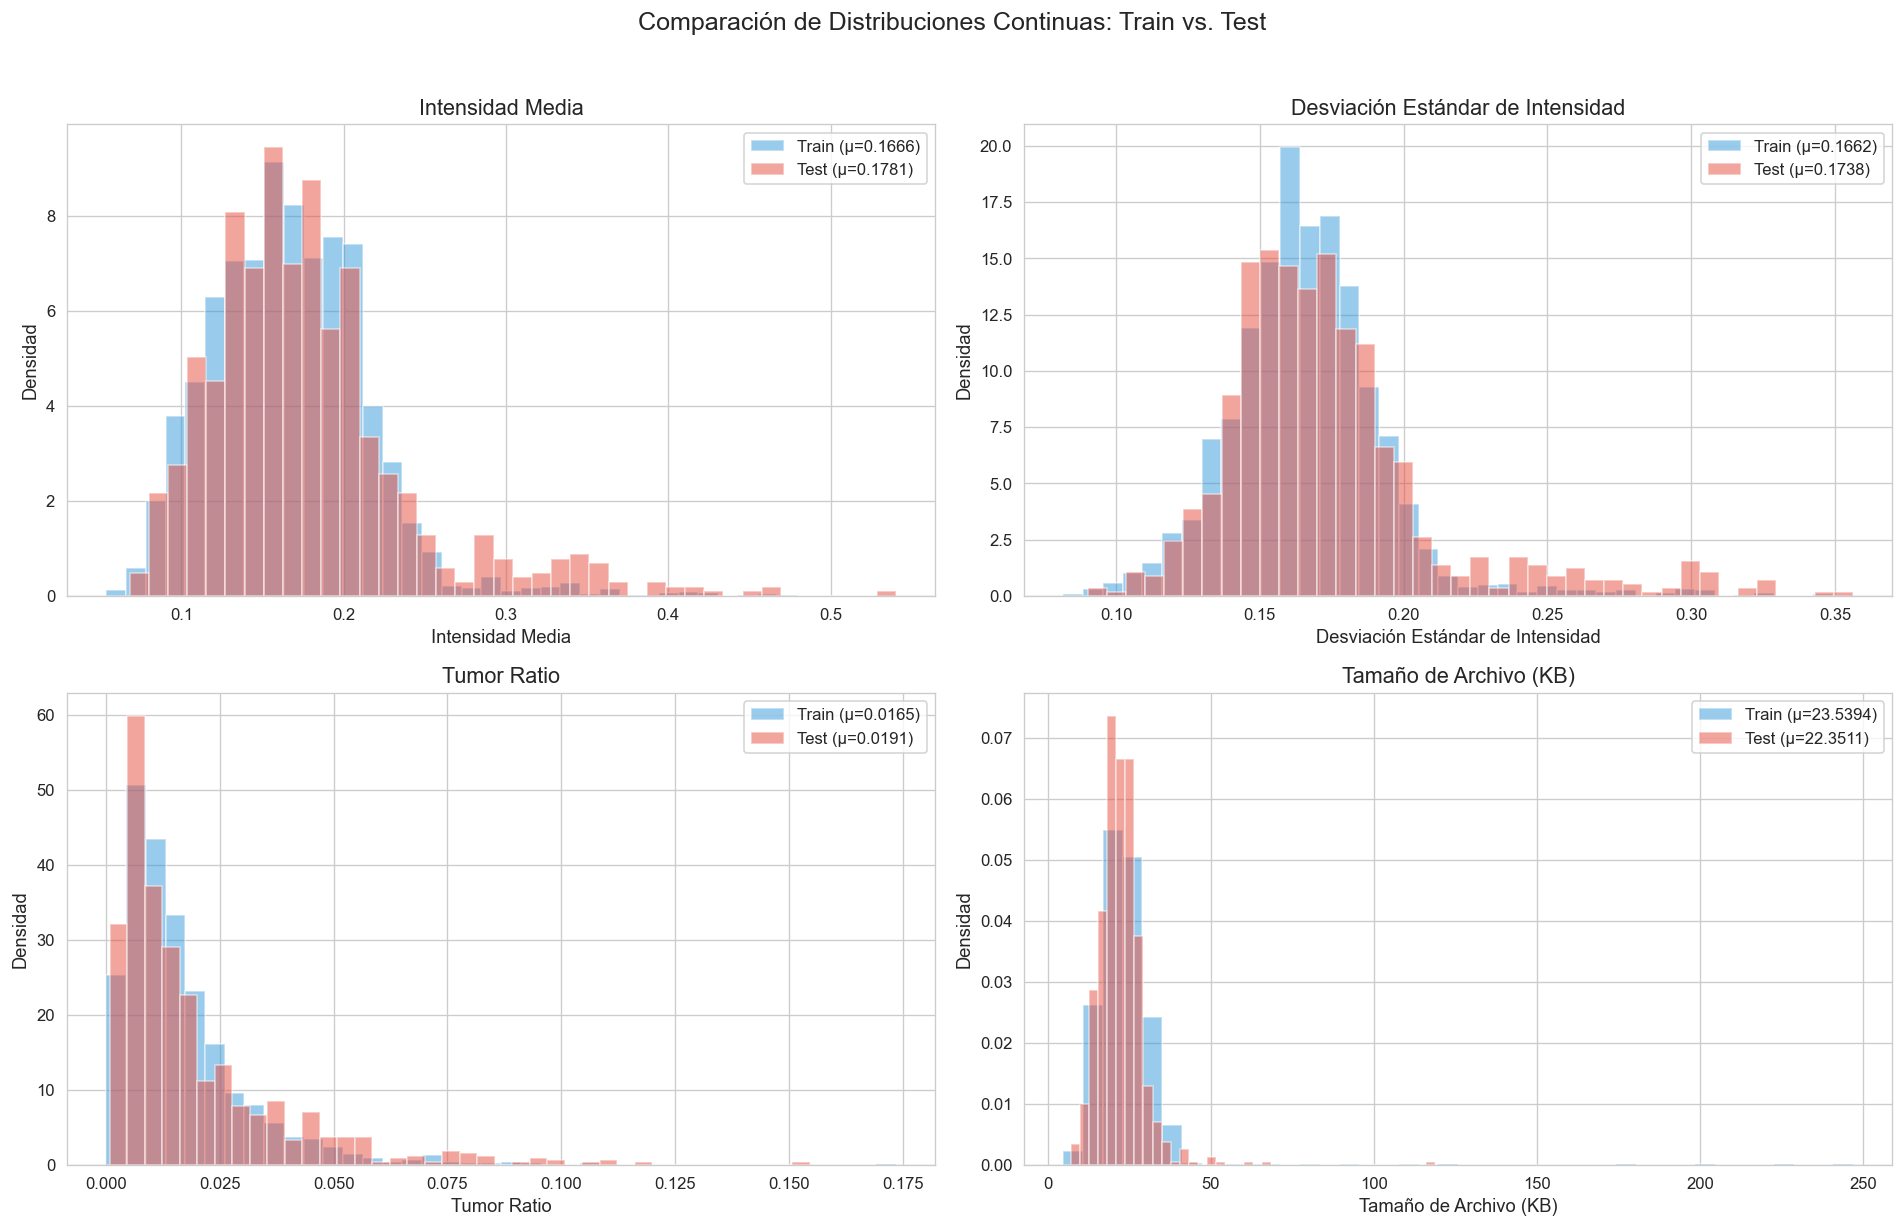

In [16]:
continuous_vars = {
    'mean_intensity': 'Intensidad Media',
    'std_intensity':  'Desviación Estándar de Intensidad',
    'tumor_ratio':    'Tumor Ratio',
    'file_size_kb':   'Tamaño de Archivo (KB)',
}

print(" Pruebas de Homogeneidad: Train vs. Test (variables continuas)")
print("="*75)
print(f"{'Variable':<30} {'Mann-Whitney U':>15} {'p-MW':>10} {'KS stat':>10} {'p-KS':>10} {'Resultado':>12}")
print("─"*75)

results_homogeneity = []

for col, label in continuous_vars.items():
    train_vals = df[df['split'] == 'Train'][col].dropna()
    test_vals = df[df['split'] == 'Test'][col].dropna()
    
    u, p_mw = mannwhitneyu(train_vals, test_vals, alternative='two-sided')
    ks, p_ks = ks_2samp(train_vals, test_vals)
    
    is_homo = "Homogéneo" if (p_mw > 0.05 and p_ks > 0.05) else "Difiere"
    
    print(f"  {label:<28} {u:>15.1f} {p_mw:>10.4f} {ks:>10.4f} {p_ks:>10.4f} {is_homo:>12}")
    
    results_homogeneity.append({
        'Variable': label, 'U': u, 'p_MW': p_mw,
        'KS': ks, 'p_KS': p_ks, 'Homogeneous': p_mw > 0.05 and p_ks > 0.05
    })

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (col, label) in enumerate(continuous_vars.items()):
    ax = axes[idx // 2, idx % 2]
    train_vals = df[df['split'] == 'Train'][col].dropna()
    test_vals = df[df['split'] == 'Test'][col].dropna()
    
    ax.hist(train_vals, bins=40, alpha=0.5, label=f'Train (μ={train_vals.mean():.4f})',
            color=SPLIT_PALETTE['Train'], density=True, edgecolor='white')
    ax.hist(test_vals, bins=40, alpha=0.5, label=f'Test (μ={test_vals.mean():.4f})',
            color=SPLIT_PALETTE['Test'], density=True, edgecolor='white')
    ax.set_title(f'{label}')
    ax.set_xlabel(label)
    ax.set_ylabel('Densidad')
    ax.legend()

fig.suptitle('Comparación de Distribuciones Continuas: Train vs. Test', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('eda_homogeneity_train_test.png', dpi=150, bbox_inches='tight')
plt.show()


Se identificó un fenómeno de **desplazamiento distributivo estadísticamente significativo** entre las particiones de entrenamiento y prueba (Fig. X). Las pruebas de Kolmogorov-Smirnov confirmaron que las distribuciones de Intensidad Media ($KS=0.073, p<0.001$) y Desviación Estándar ($KS=0.085, p<0.001$) difieren significativamente.

Este hallazgo es consistente con el desbalance de planos anatómicos detectado previamente en la Sección 3.3.4, donde el plano Axial —que presenta perfiles de intensidad y proporciones de fondo distintos— predomina en el set de evaluación. Notablemente, para el **Tumor Ratio**, aunque no se hallaron diferencias en las medianas (MWU $p=0.53$), el test KS ($p=0.001$) confirma una disparidad en la estructura de la distribución, sugiriendo que el conjunto de prueba contiene una mayor diversidad de tamaños tumorales.

**Implicación Científica:** Lejos de invalidar el estudio, esta heterogeneidad refuerza la validez de los resultados futuros: si el modelo propuesto logra un mIoU alto en el set de prueba a pesar de estas diferencias distributivas, se demostrará una **capacidad de generalización superior** y una alta robustez ante variaciones radiométricas y morfológicas.

## 3.9 Inspección Cualitativa y Validación Visual de Anotaciones

La comprensión de la morfología tumoral en el espacio tridimensional requiere una inspección de los tres planos de corte. En esta sección se presenta una galería representativa donde, para cada intersección de `tumor_label` y `plane_label`, se ha seleccionado el espécimen cuya área tumoral ($Tumor Ratio$) se aproxima a la mediana de su categoría. Esta visualización permite verificar la **fidelidad de las máscaras de segmentación** respecto a los bordes anatómicos visibles en la secuencia T1 y observar la variabilidad de contraste y textura interna de las lesiones. El uso de superposiciones (*overlays*) facilita la evaluación de la calidad del *ground truth* proporcionado por los expertos, paso previo esencial al entrenamiento de los modelos de Deep Learning.



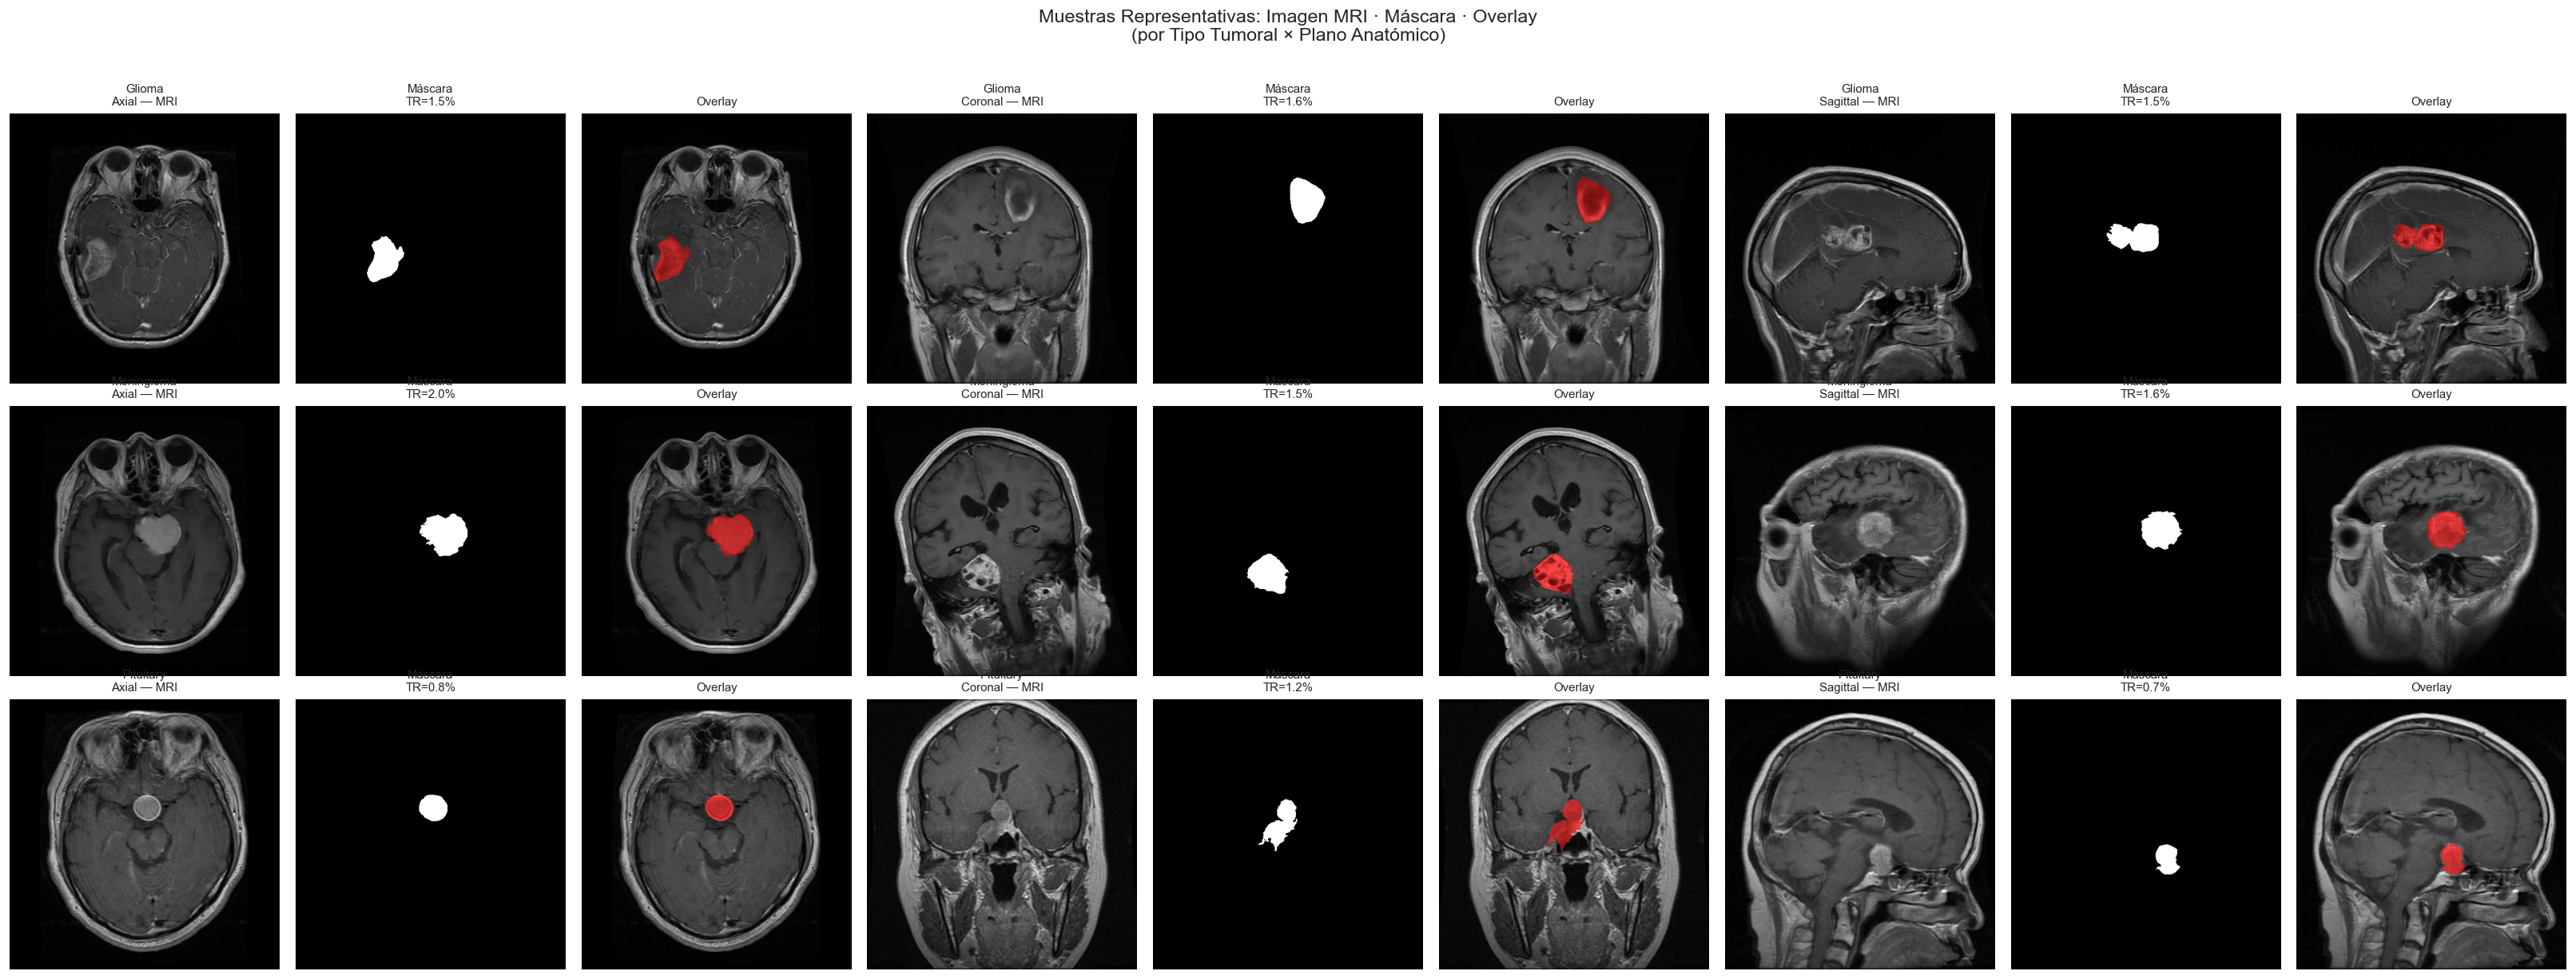

In [17]:
tumors = ['Glioma', 'Meningioma', 'Pituitary']
planes = ['Axial', 'Coronal', 'Sagittal']

fig, axes = plt.subplots(3, 9, figsize=(27, 10))

for i, tumor in enumerate(tumors):
    for j, plane in enumerate(planes):
        subset = df[(df['tumor_label'] == tumor) & (df['plane_label'] == plane) & (df['split'] == 'Train')]
        if len(subset) == 0:
            continue
        
        median_ratio = subset['tumor_ratio'].median()
        sample = subset.iloc[(subset['tumor_ratio'] - median_ratio).abs().argsort().iloc[0]]
        
        img = np.array(Image.open(sample['image_path']).convert('L'))
        mask = np.array(Image.open(sample['mask_path']).convert('L'))
        mask_binary = (mask > 127).astype(np.uint8)
        
        overlay = np.stack([img, img, img], axis=-1)  # RGB
        overlay[mask_binary == 1, 0] = np.clip(overlay[mask_binary == 1, 0].astype(int) + 80, 0, 255)
        overlay[mask_binary == 1, 1] = (overlay[mask_binary == 1, 1] * 0.4).astype(np.uint8)
        overlay[mask_binary == 1, 2] = (overlay[mask_binary == 1, 2] * 0.4).astype(np.uint8)
        
        col_base = j * 3
        
        axes[i, col_base].imshow(img, cmap='gray')
        axes[i, col_base].set_title(f'{tumor}\n{plane} — MRI', fontsize=9)
        axes[i, col_base].axis('off')
        
        axes[i, col_base + 1].imshow(mask_binary, cmap='gray')
        axes[i, col_base + 1].set_title(f'Máscara\nTR={sample["tumor_ratio"]*100:.1f}%', fontsize=9)
        axes[i, col_base + 1].axis('off')
        
        axes[i, col_base + 2].imshow(overlay)
        axes[i, col_base + 2].set_title(f'Overlay', fontsize=9)
        axes[i, col_base + 2].axis('off')

fig.suptitle('Muestras Representativas: Imagen MRI · Máscara · Overlay\n(por Tipo Tumoral × Plano Anatómico)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_sample_gallery.png', dpi=150, bbox_inches='tight')
plt.show()


La inspección cualitativa de las muestras representativas confirma una alta correspondencia entre las señales de hiperintensidad en MRI T1-ce y las máscaras de segmentación. 

**Hallazgos Clave:**
1.  **Consistencia Anatómica:** Los tumores hipofisarios (*Pituitary*) muestran una localización focalizada y dimensiones reducidas, validando los resultados estadísticos de la Sección 3.6.
2.  **Morfología por Plano:** Se observa cómo el plano **Sagital** proporciona una vista crítica de la extensión vertical de los meningiomas, mientras que el plano **Axial** delimita mejor la infiltración lateral en gliomas.
3.  **Calidad de Anotación:** La superposición de máscaras revela una delimitación precisa de los bordes tumorales, sin evidencia de desplazamientos (*misalignment*) significativos entre las imágenes `.jpg` y las máscaras `.png`. 

Esta inspección visual, sumada al análisis estadístico previo, concluye que el dataset BRISC 2025 es apto para el entrenamiento de arquitecturas de segmentación de alta precisión, poseyendo un *ground truth* robusto y clínicamente coherente.

In [18]:
output_path = os.path.join(base_path, 'eda_dataframe_enriched.csv')
df.to_csv(output_path, index=False)
print(f"💾 DataFrame enriquecido guardado en: {output_path}")
print(f"   ({len(df)} filas × {len(df.columns)} columnas)")
print(f"\n   Columnas disponibles: {list(df.columns)}")


💾 DataFrame enriquecido guardado en: C:\Users\johan\Downloads\Proyectos academicos\imagenes_tumores_cerebrales\brisc2025\eda_dataframe_enriched.csv
   (4793 filas × 37 columnas)

   Columnas disponibles: ['filename', 'split', 'index', 'tumor_code', 'tumor_label', 'plane_code', 'plane_label', 'sequence', 'image_path', 'mask_path', 'mask_exists', 'tumor_plane', 'width', 'height', 'aspect_ratio', 'resolution', 'num_pixels', 'color_mode', 'file_size_kb', 'mean_intensity', 'std_intensity', 'median_intensity', 'min_intensity', 'max_intensity', 'skewness', 'kurtosis', 'pct_black', 'mask_width', 'mask_height', 'tumor_pixels', 'bg_pixels', 'total_pixels', 'tumor_ratio', 'bg_ratio', 'is_empty_mask', 'is_full_mask', 'unique_values']


## Síntesis del EDA y Decisiones para el Preprocesamiento

A partir de los hallazgos del análisis exploratorio, se establecen las siguientes decisiones y lineamientos para la fase de preprocesamiento:

### Hallazgos principales

| # | Hallazgo | Impacto |
|---|----------|---------|
| 1 | **140 resoluciones diferentes**, 94% son 512×512 | Requiere redimensionamiento uniforme |
| 2 | **Dos modos de color** (RGB y L) | Requiere estandarización a 1 canal |
| 3 | **Desbalance extremo tumor/fondo** (~1.7% vs. ~98.3%) | Requiere loss functions especializadas (Dice, Focal) |
| 4 | **Tipo tumoral afecta significativamente el tumor ratio** (p ≈ 0) | Reportar métricas desagregadas por clase |
| 5 | **Plano anatómico afecta significativamente el tumor ratio** (p = 2.82e-08) | Reportar métricas desagregadas por plano |
| 6 | **Distribución de planos NO es homogénea entre splits** (χ² = 42.76, p < 0.0001) | Documentar como limitación; Axial sobrerrepresentado en test |
| 7 | **Distribución de tumores SÍ es homogénea entre splits** (χ² = 1.60, p = 0.45) | Validación del split para comparaciones por clase |
| 8 | **Intensidades varían entre clases y planos** | Normalización por imagen recomendada |
| 9 | **Máscaras con valores no estrictamente binarios** (~15 valores únicos) | Binarización con umbral 127 antes del entrenamiento |
| 10 | **No se detectaron máscaras vacías ni corruptas** | Dataset íntegro para segmentación |
